In [4]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(ggplot2)
library(ggsci)
library(scales)
library(ggrepel)
library(MASS) # for glm.nb



In [5]:
# load all auxilary files
source("scripts/post_hoc/utils.R")

Classes and Methods for R developed in the
Political Science Computational Laboratory
Department of Political Science
Stanford University
Simon Jackman
hurdle and zeroinfl functions by Achim Zeileis



# 1.0 Variant level analysis

In [231]:
# this aggregation is now being accomplished in a seperate script
dt1 <- fread("data/post_hoc/results/ukb_wes_union_calls_200k_variants.pp90_prefilter.txt.gz")
dt2 <- fread("data/post_hoc/results/ukb_wes_union_calls_200k_variants.pp90_postfilter.txt.gz")
stopifnot((dt1$variant_category == dt2$variant_category) & (dt1$consequence_category == dt2$consequence_category))

In [232]:
dt2_filter <- dt2[,c("n_total","n_singletons","pct_singletons")]
colnames(dt2_filter) <- paste0("filter_",colnames(dt2_filter))
combi <- cbind(dt1, dt2_filter)
combi

super_category,consequence_category,variant_category,n_total,n_singletons,pct_singletons,filter_n_total,filter_n_singletons,filter_pct_singletons
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
PTV,damaging_missense,frameshift_variant,18513,8841,47.8,18304,8744,47.8
PTV,pLoF,frameshift_variant,129686,72273,55.7,127615,71145,55.7
PTV,damaging_missense,splice_acceptor_variant,941,503,53.5,895,474,53.0
PTV,pLoF,splice_acceptor_variant,26551,15269,57.5,26187,15071,57.6
PTV,damaging_missense,splice_donor_variant,502,251,50.0,467,231,49.5
PTV,pLoF,splice_donor_variant,34729,18865,54.3,34266,18616,54.3
PTV,damaging_missense,stop_gained,12772,5693,44.6,12610,5630,44.6
PTV,pLoF,stop_gained,103567,53166,51.3,101913,52351,51.4
PTV,damaging_missense,,32728,15288,46.7,32276,15079,46.7


In [46]:
levels <- c("non_coding","synonymous", 'other_missense', 'damaging_missense', 'LC', 'pLoF')

In [47]:
dt_subset <- combi[combi$variant_category == "" & combi$consequence_category != "",]
dt_subset$consequence_category <- factor(as.character(dt_subset$consequence_category), levels = levels)
#dt_subset$consequence_category[1] <- "LC"

In [48]:
dt_combi <- rbind(
    data.frame(
        super_category = dt_subset$super_category,
        variant_category = dt_subset$variant_category,
        consequence_category = dt_subset$consequence_category,
        is_singleton = FALSE,
        n = dt_subset$filter_n_total
    ),
    data.frame(
        super_category = dt_subset$super_category,
        variant_category = dt_subset$variant_category,
        consequence_category = dt_subset$consequence_category,
        is_singleton = TRUE,
        n = dt_subset$filter_n_singletons
    )
)

In [49]:
dt_combi$consequence_category <- factor(as.character(dt_combi$consequence_category), levels = levels)
dt_combi <- dt_combi[dt_combi$consequence_category %in% c("pLoF","damaging_missense"),]

In [11]:
#options(repr.plot.width=9, repr.plot.height=3)
#colfunc<-colorRampPalette(c("#65B8EF","white")) #(c("#7BA98A", "#65B8EF" ))#(c("tomato2","yellow","springgreen3","royalblue"))
#plot(rep(1,50),col=(colfunc(50)), pch=19,cex=2)
#colors <- colfunc(5)

In [12]:
#my_colors <- rev(colfunc(6))
#names(my_colors) <- levels
#fill_scale <- scale_fill_manual(name = "consequence_category", values = my_colors)
#color_scale <- scale_color_manual(name = "consequence_category", values = my_colors)

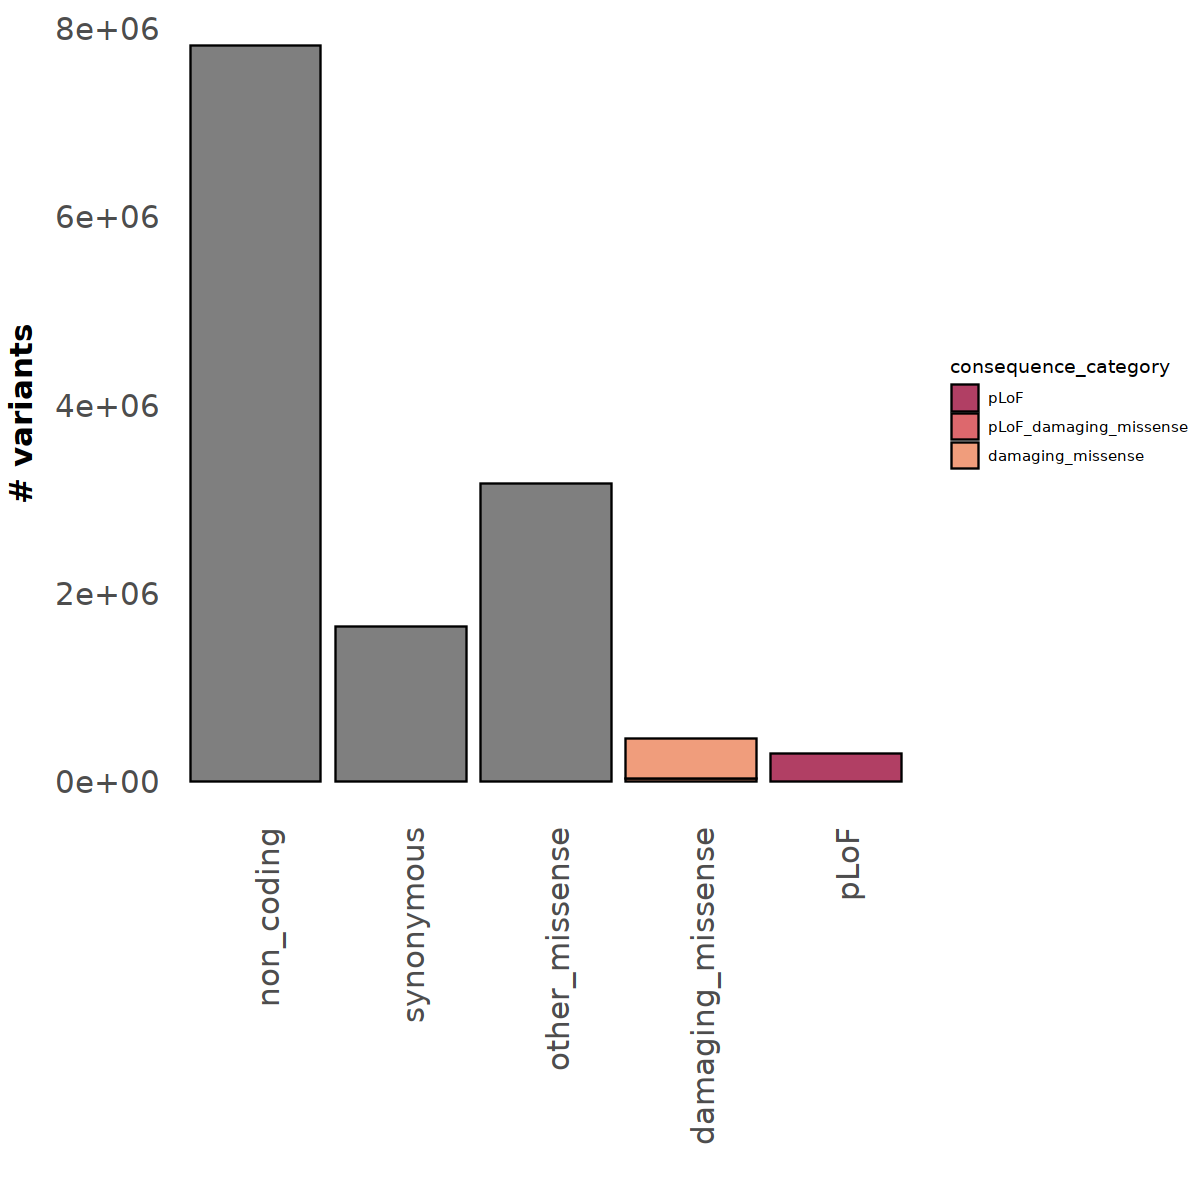

In [58]:
options(repr.plot.width=10, repr.plot.height=10)
p1 <- ggplot(dt_subset, aes(x=consequence_category, y=n_total, fill=consequence_category)) +
    #scale_y_continuous(trans='log10') +
    geom_bar(stat="identity", color = 'black') +
    xlab("") +
    ylab("# variants") +
    #scale_y_continuous(
    #    breaks=scales::pretty_breaks(n=10), 
    #    labels = scales::comma #function(x) format(x, scientific = FALSE)
    #    ) +
    fill_scale +
    theme_minimal() +
    theme(
        legend.position = "right",
        strip.text = element_text(size=18),
        axis.text=element_text(size=18),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
print(p1)

,super_category,variant_category,consequence_category,is_singleton,n
,<chr>,<chr>,<fct>,<lgl>,<int>
1,PTV,,damaging_missense,FALSE,32276
2,PTV,,pLoF,FALSE,289981
3,Missense,,damaging_missense,FALSE,412528
7,PTV,,damaging_missense,TRUE,15079
8,PTV,,pLoF,TRUE,157183
9,Missense,,damaging_missense,TRUE,200464


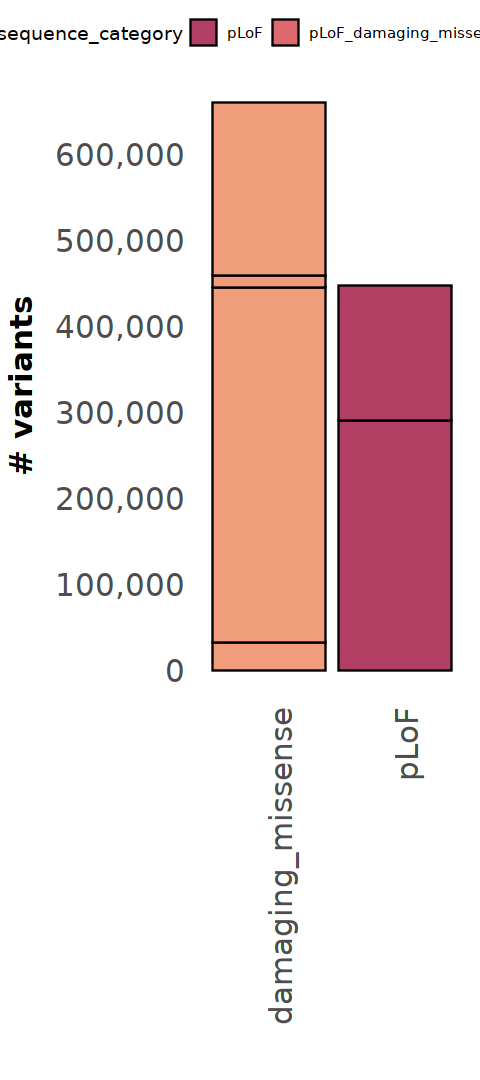

In [59]:
options(repr.plot.width=4, repr.plot.height=9)
dt_combi
p1 <- ggplot(dt_combi, aes(x=consequence_category, y=n, fill=consequence_category)) +
    #scale_y_continuous(trans='log10') +
    geom_bar(stat="identity", color = 'black') +
    #xlab("Consequence Category") +
    xlab("") +
    ylab("# variants") +
    fill_scale +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=10), 
        labels = scales::comma #function(x) format(x, scientific = FALSE)
        ) +
    theme_minimal() +
    theme(
        legend.position = "top",
        strip.text = element_text(size=18),
        axis.text=element_text(size=18),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
print(p1)

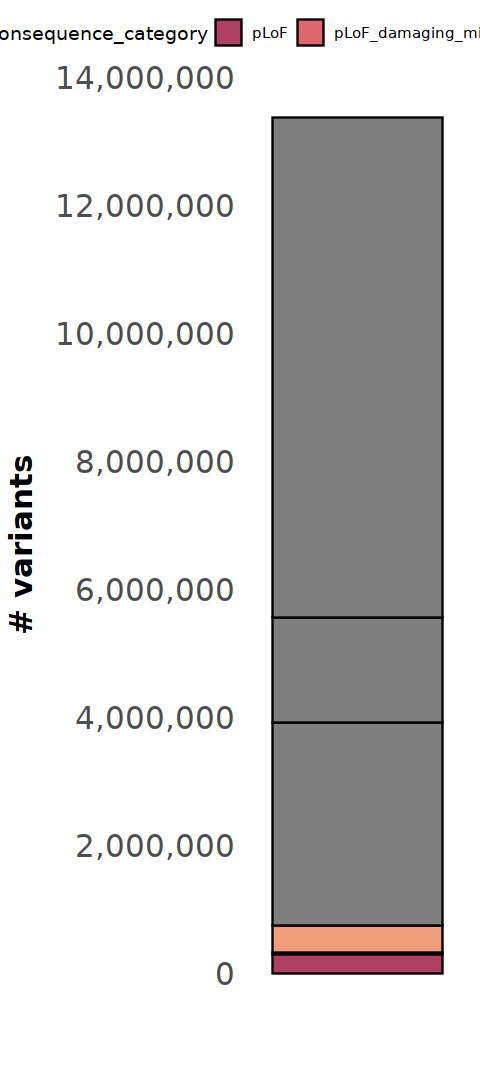

In [60]:
options(repr.plot.width=4, repr.plot.height=9)
p1 <- ggplot(dt_subset, aes(x="", y=n_total, fill=consequence_category)) +
    #scale_y_continuous(trans='log10') +
    geom_bar(stat="identity", color = 'black') +
    #xlab("Consequence Category") +
    xlab("") +
    ylab("# variants") +
    fill_scale +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=10), 
        labels = scales::comma #function(x) format(x, scientific = FALSE)
        ) +
    theme_minimal() +
    theme(
        legend.position = "top",
        strip.text = element_text(size=18),
        axis.text=element_text(size=18),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
print(p1)

## 1.9 Variant by sample statistic

In [12]:
annotations <- c("pLoF", "pLoF_damaging_missense", "damaging_missense")

In [9]:
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [18]:
#cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id", )
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
#dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

In [19]:
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL
dt$annotation <- factor(dt$annotation, levels = annotations)

In [20]:
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

In [23]:
full <- dt[dt$annotation == "damaging_missense"]

s,gene_id,transcript_id,varid,gts,AC,AF,AN,hom_alt_n,phased.a1,⋯,most_severe_consequence,revel_score,cadd_phred,exon,intron,annotation,is_chet,is_cis,is_hom,is_ko
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<lgl>,<lgl>,<lgl>,<lgl>
3010034,ENSG00000004455,ENST00000354858,chr1:33013390:G:T;chr1:33013393:C:T,1|0;1|0,2;3,5.6629e-06;8.4944e-06,353174;353174,0,2,⋯,missense_variant;missense_variant,0.752;0.854,26.6;28.2,6/6;6/6,,damaging_missense,FALSE,TRUE,FALSE,FALSE
5643583,ENSG00000004455,ENST00000354858,chr1:33013390:G:T;chr1:33013393:C:T,0|1;0|1,2;3,5.6629e-06;8.4944e-06,353174;353174,0,0,⋯,missense_variant;missense_variant,0.752;0.854,26.6;28.2,6/6;6/6,,damaging_missense,FALSE,TRUE,FALSE,FALSE
1997561,ENSG00000007933,ENST00000367755,chr1:171107811:C:T,1|1,1266,0.0035846,353174,1,0,⋯,missense_variant,0.759,24.2,4/9,NA,damaging_missense,FALSE,FALSE,TRUE,TRUE
2833182,ENSG00000007933,ENST00000367755,chr1:171092652:G:C;chr1:171107811:C:T,0|1;1|0,5;1266,1.4157e-05;0.0035846,353174;353174,0,1,⋯,splice_acceptor_variant;missense_variant,0.759,24.2,4/9,1/8,damaging_missense,TRUE,FALSE,FALSE,TRUE
5650231,ENSG00000008128,ENST00000378633,chr1:1704621:T:C,1|1,23,6.5124e-05,353174,1,0,⋯,missense_variant,0.632,25.8,14/20,NA,damaging_missense,FALSE,FALSE,TRUE,TRUE
1101125,ENSG00000009709,ENST00000375375,chr1:18634420:G:A;chr1:18691811:G:A,0|1;0|1,15;270,4.2472e-05;0.0007645,353174;353174,0,0,⋯,missense_variant;missense_variant,0.963;0.863,32;28.2,2/8;5/8,,damaging_missense,FALSE,TRUE,FALSE,FALSE
1259391,ENSG00000009709,ENST00000375375,chr1:18634420:G:A;chr1:18691811:G:A,1|0;1|0,15;270,4.2472e-05;0.0007645,353174;353174,0,2,⋯,missense_variant;missense_variant,0.963;0.863,32;28.2,2/8;5/8,,damaging_missense,FALSE,TRUE,FALSE,FALSE
1810871,ENSG00000009709,ENST00000375375,chr1:18635124:C:T;chr1:18635190:G:A,1|0;0|1,1157;5,0.003276;1.4157e-05,353174;353174,0,1,⋯,missense_variant;missense_variant,0.954;0.955,28.1;32,3/8;3/8,,damaging_missense,TRUE,FALSE,FALSE,TRUE
1936036,ENSG00000009709,ENST00000375375,chr1:18635124:C:T;chr1:18691811:G:A,0|1;1|0,1157;270,0.003276;0.0007645,353174;353174,0,1,⋯,missense_variant;missense_variant,0.954;0.863,28.1;28.2,3/8;5/8,,damaging_missense,TRUE,FALSE,FALSE,TRUE


# 2.0 Knockout level

## 2.0 How many knockouts per category (including non-coding/other):

In [ ]:
annotations <- c("pLoF", "pLoF_damaging_missense", "damaging_missense", "other_missense", "synoymous")
pLoF <- read_ukb_wes_kos("pLoF", allow_hets = FALSE)
damaging_missense <- read_ukb_wes_kos("damaging_missense", allow_hets = FALSE)
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense",allow_hets = FALSE)
synoymous <- read_ukb_wes_kos("synonymous", allow_hets = FALSE)
other_missense <- read_ukb_wes_kos("other_missense", allow_hets = FALSE)

## 2.1. How many knockouts per category?

In [ ]:
annotations <- c("pLoF", "pLoF_damaging_missense", "damaging_missense")

In [197]:
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

In [198]:
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [212]:
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

In [213]:
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL
dt$annotation <- factor(dt$annotation, levels = annotations)

In [214]:
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

In [215]:
# melt accordingly
melted <- melt(dt, measure.vars = c("is_chet","is_hom","is_cis"))
aggr <- aggregate(value~variable+annotation, data = melted, FUN = sum)
aggr$annotation <- factor(aggr$annotation, levels = annotations)

In [216]:
categories <- annotations
my_colors <- c("#B13F64","#DD686D", "#F09D7C")
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "consequence_category", values = my_colors)
color_scale <- scale_color_manual(name = "consequence_category", values = my_colors)

In [217]:
newnames <- c(
    "is_chet" = "Compound  \nheterozygote",
    "is_hom" = "Homozygote",
    "is_cis" = "Two-hit (cis)"
)
aggr$label <- newnames[aggr$variable]
aggr$value_k <- scales::label_number_si(accuracy = 0.1)(aggr$value)

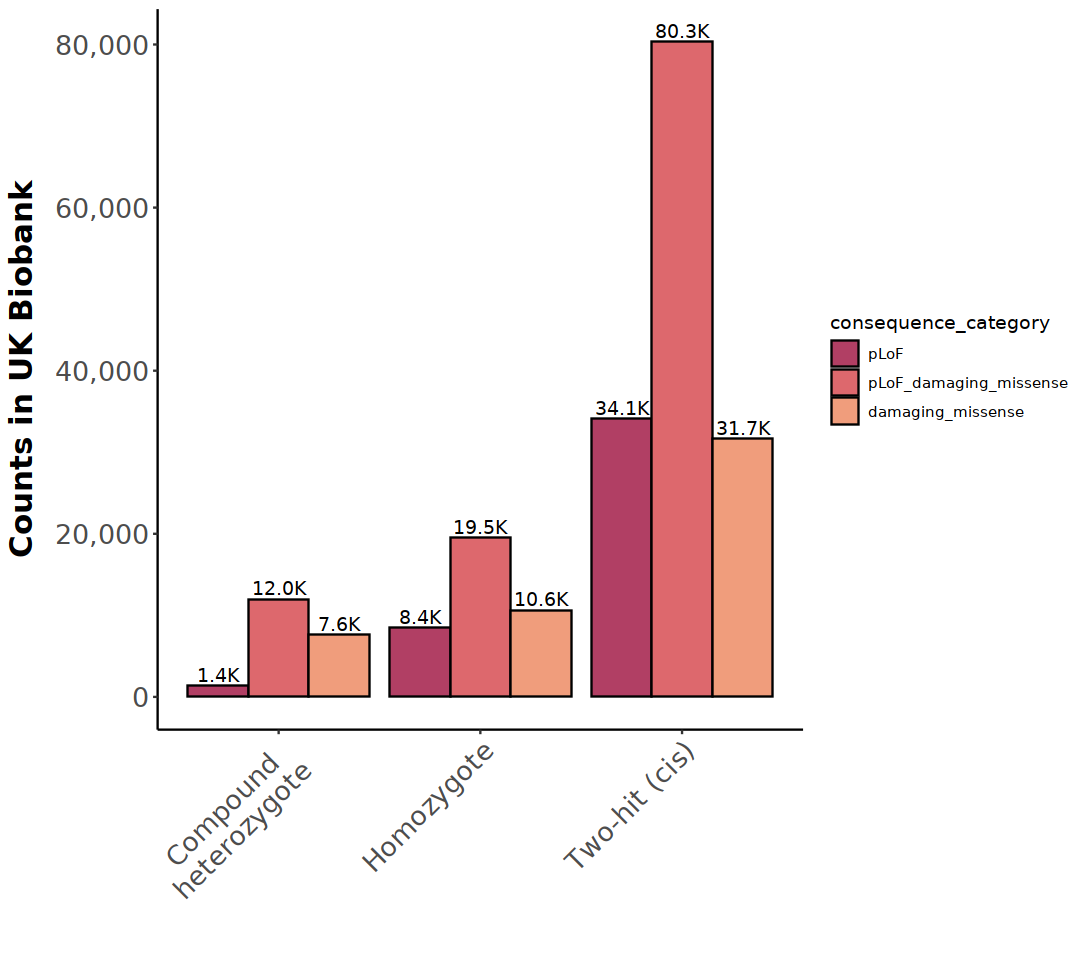

In [218]:
options(repr.plot.width=9, repr.plot.height=8)
pd <- position_dodge()
p <- ggplot(aggr, aes(x=label, y=value, fill = annotation, group=annotation)) +
    geom_bar(stat='identity', position="dodge", color = 'black') +
    theme_classic() +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=5), 
        labels = scales::comma
    ) +
    ylab("Counts in UK Biobank") +
    xlab("") +
    fill_scale +
    theme_classic() +
    geom_text(aes(x=label, label=value_k), position=position_dodge(width=0.9), vjust=-0.28) +
    theme(
        legend.position = "right",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        axis.text.x = element_text(angle = 45, hjust = 0.99, vjust = 0.99),
        plot.title = element_text(hjust=0.5),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
p

In [88]:
out_prefix <- "derived/plots/221219_ko_count_ukbb_by_consequence_and_type"
ggsave(paste0(out_prefix, ".pdf"), p, width = 10, height = 9)
fwrite(aggr, paste0(out_prefix, ".txt"))

## 2.2 Number of knockouts per gene

In [219]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [220]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

In [221]:
dt_ko_only  <- dt[dt$is_ko,]

In [222]:
# count number of knockout carries per gene
ko_per_gene <- data.table(table(dt_ko_only$gene_id, dt_ko_only$annotation))
colnames(ko_per_gene) <- c("gene_id","annotation","N")
ko_per_gene <- ko_per_gene[ko_per_gene$N > 0,]
ko_per_gene <- data.table(table(ko_per_gene$N, ko_per_gene$annotation))
colnames(ko_per_gene) <- c("kos","annotation","N")
levels <- unique(as.character(sort(as.numeric(ko_per_gene$kos))))
ko_per_gene$kos_count <- as.numeric(ko_per_gene$kos)
ko_per_gene$kos <- factor(as.character(ko_per_gene$kos), levels = levels)

# aggregate anything above a certain threshold
kos_limit <- 10
kos_with_limit <- ko_per_gene[ko_per_gene$kos_count >= kos_limit, ]
kos_with_limit <- setDT(aggregate(N~annotation, FUN=sum, data=kos_with_limit))
kos <- paste0(kos_limit,"+")
kos_with_limit <- cbind(kos, kos_with_limit)

# clean up original and append
ko_per_gene <- ko_per_gene[ko_per_gene$kos_count < kos_limit, ]
ko_per_gene$kos_count <- NULL
combined <- rbind(ko_per_gene, kos_with_limit)
combined$annotation <- factor(combined$annotation, levels = annotations)

In [223]:
levels(combined$annotation)

[1] "pLoF"                   "pLoF_damaging_missense" "damaging_missense"

In [224]:
categories <- levels(combined$annotation)
my_colors <- c("#B13F64","#DD686D", "#F09D7C")
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "consequence_category", values = my_colors)
color_scale <- scale_color_manual(name = "consequence_category", values = my_colors)

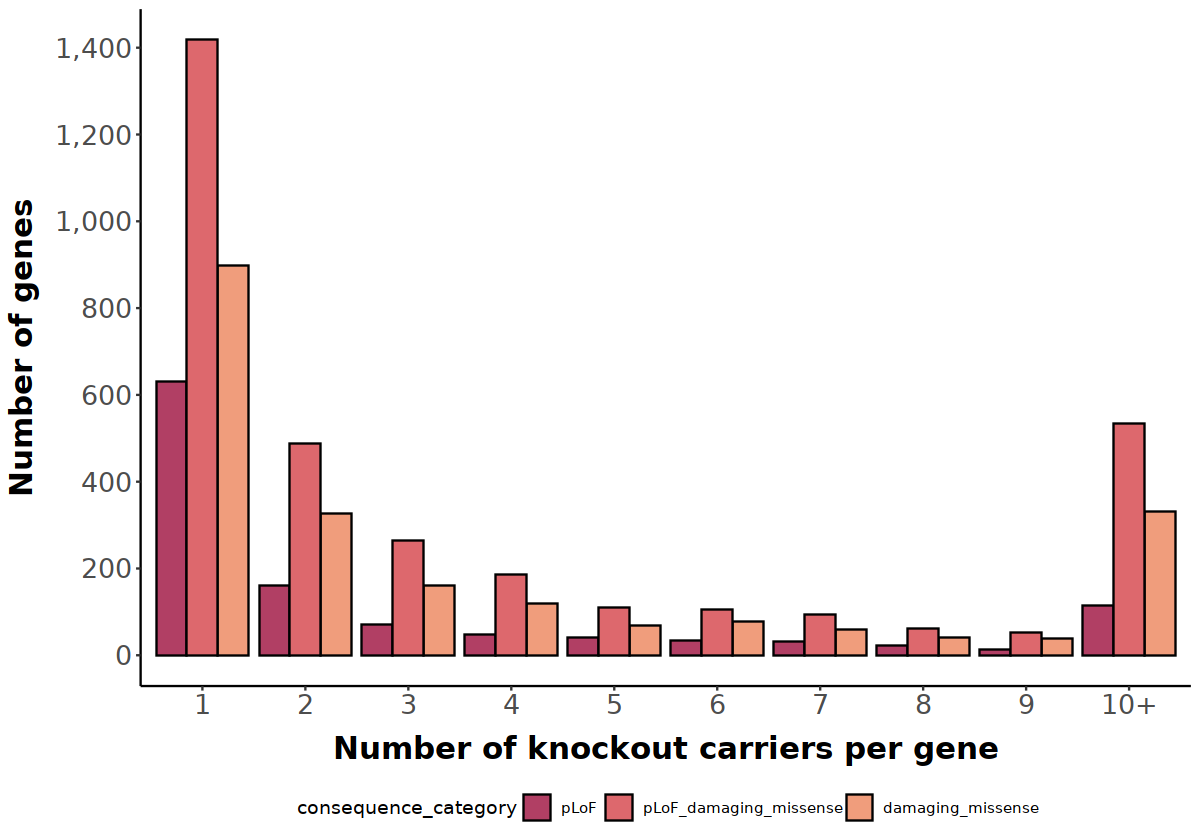

In [225]:
options(repr.plot.width=10, repr.plot.height=7)
ggplot(combined, aes(x=kos, y=N, fill=annotation)) +
    geom_bar(stat='identity', position="dodge", color = 'black') +
    coord_cartesian(xlim = c(1,10)) +
    theme_classic() +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=10), 
        labels = scales::comma
    ) +
    fill_scale +
    xlab("Number of knockout carriers per gene") +
    ylab("Number of genes") +
    #scale_y_continuous(trans = 'log10', breaks=c(10, 500, 1000, 2000)) +    
    #annotation_logticks(sides='l')  +
    theme(
        legend.position = "bottom",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    )

In [226]:
out_prefix <- "derived/plots/221219_ko_carriers_per_gene_by_csqs"
ggsave(paste0(out_prefix, ".pdf"), p, width = 10, height = 7)
fwrite(aggr, paste0(out_prefix, ".txt"))

## 2.3 Compound het allele frequency distributions

In [125]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [126]:
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]
dt <- dt[dt$intron == "",]

In [127]:
annotations <- c("pLoF","damaging_missense","pLoF_damaging_missense")
subsets <- list(chet=dt[dt$is_chet,], cis=dt[dt$is_cis,])

In [128]:
ac_count <- do.call(rbind,lapply(names(subsets), function(subset_name){
    dt_subset <- subsets[[subset_name]]
    inner_list <- do.call(rbind, lapply(annotations, function(anno){
        full <- dt_subset[dt_subset$annotation %in% anno,]
        ac <- do.call(rbind, lapply(1:nrow(full), function(idx){
            ac_field <- full$AC[idx]
            an_field <- full$AN[idx]
            var_field <- full$varid[idx]
            splitted_an <- as.numeric(unlist(strsplit(an_field, split = ';')))
            splitted_ac <- as.numeric(unlist(strsplit(ac_field, split = ';')))
            splitted_var <- as.numeric(gsub("\\:","",unlist(stringr::str_extract_all(var_field, pattern = ":[0-9]+:"))))
            pos1 <- splitted_var[1]
            pos2 <- splitted_var[2]
            an1 <- splitted_an[1]
            an2 <- splitted_an[2]
            ac1 <- splitted_ac[1]
            ac2 <- splitted_ac[2]
            out <- data.frame(ac1, ac2, an1, an2, pos1, pos2)
            out$annotation <- anno
            out$subset <- subset_name
            return(out)
        }))
        return(ac)
    }))
    return(inner_list)
}))

In [129]:
ac_count$dist <- abs(ac_count$pos1 - ac_count$pos2)

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Warning message:
"Removed 26 rows containing non-finite values (stat_bin)."
Warning message:
"Transformation introduced infinite values in continuous y-axis"
Warning message:
"Removed 5 rows containing missing values (geom_bar)."


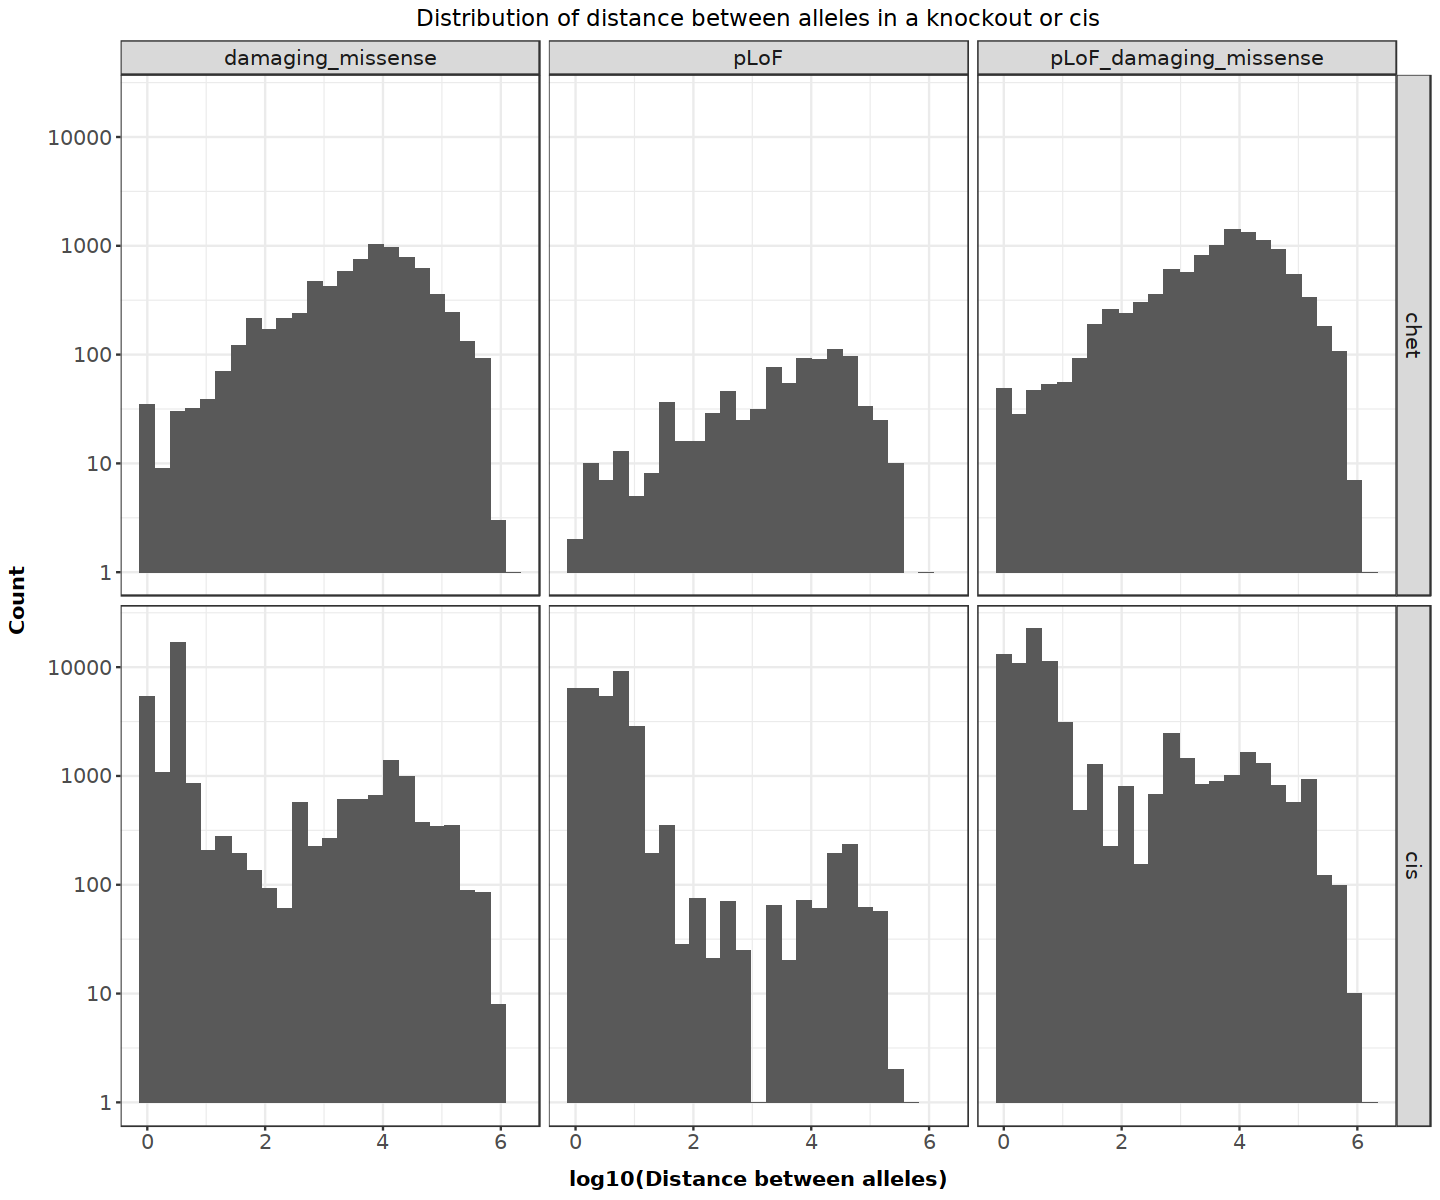

In [130]:
options(repr.plot.width=12, repr.plot.height=10)
ggplot(ac_count, aes(x=log10(dist))) +
    geom_histogram(bins = 25) +
    xlab("log10(Distance between alleles)") +
    ylab("Count") +
    ggtitle("Distribution of distance between alleles in a knockout or cis") + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_log10() +
    theme_bw() +
    theme(
        legend.position = "right",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
    ) +
    facet_grid(subset~annotation)


In [131]:
p1 <- ggplot(ac_count[ac_count$subset == "chet",], aes(x=log10(ac1),y=log10(ac2))) +
    geom_density_2d_filled(alpha = 0.8, adjust = 3/4) +
    geom_density_2d(colour = "black", adjust = 3/4) +
    xlab("Haplotype 1 log10(MAC)") +
    ylab("Haplotype 2 log10(MAC)") +
    ggtitle("Compound Heterozygous knockouts") + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    theme_bw() +
    theme(
        legend.position = "right",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
    ) +
    facet_grid(~annotation)

p2 <- ggplot(ac_count[ac_count$subset == "cis",], aes(x=log10(ac1),y=log10(ac2))) +
    geom_density_2d_filled(alpha = 0.8, adjust = 3/4) +
    geom_density_2d(colour = "black", adjust = 3/4) +
    xlab("Haplotype 1 log10(MAC)") +
    ylab("Haplotype 2 log10(MAC)") +
    ggtitle("Two-het cis") + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    theme_bw() +
    theme(
        legend.position = "right",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
    ) +
    facet_grid(~annotation)

In [173]:
options(repr.plot.width=12, repr.plot.height=6)
ac_count$delta_ac <- abs(ac_count$ac1 - ac_count$ac2)
full <- ac_count

In [181]:
pvalues <- lapply(unique(full$annotation), function(anno){
    d_subset <- full[full$annotation %in% anno,]
    d1 <- d_subset[d_subset$subset %in% "chet",]
    d2 <- d_subset[d_subset$subset %in% "cis",]
    return(t.test(d1$delta_ac, d2$delta_ac, paired = FALSE)$p.value)
})

Warning message:
"Removed 44334 rows containing non-finite values (stat_boxplot)."


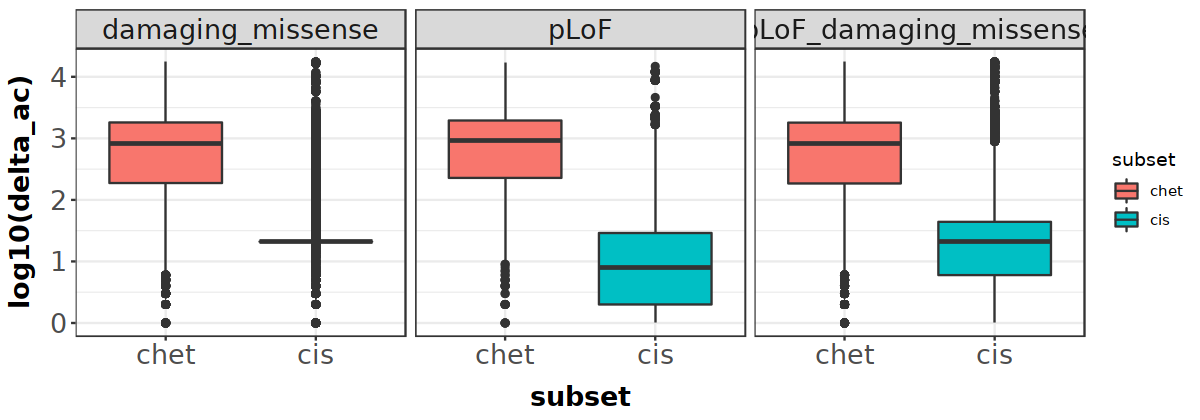

In [184]:
options(repr.plot.width=10, repr.plot.height=3.5)
ggplot(full, aes(y=log10(delta_ac), x=subset, fill=subset)) +
    geom_boxplot() + 
    theme_bw() +
    theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
    ) + 
    facet_wrap(~annotation)

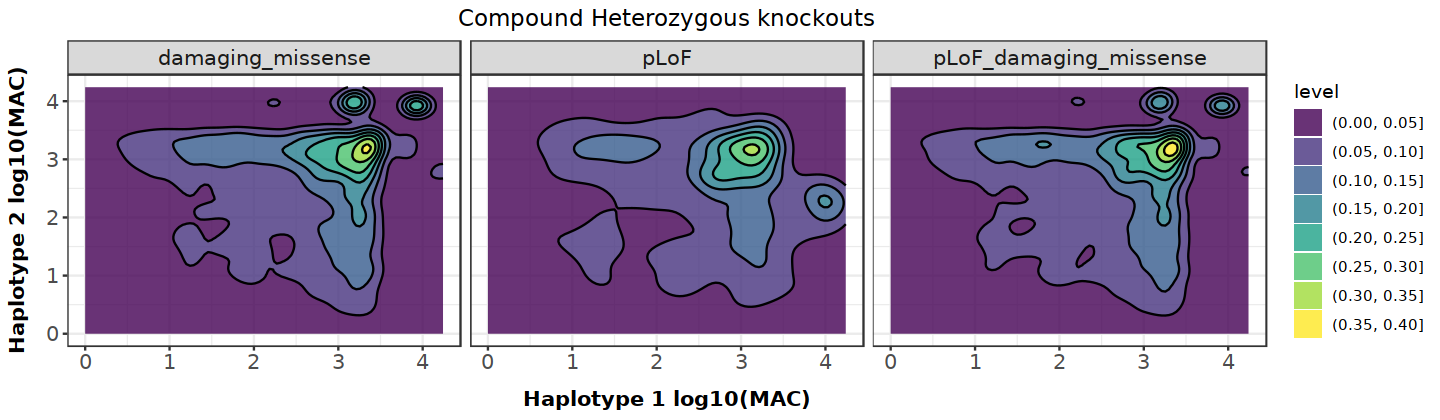

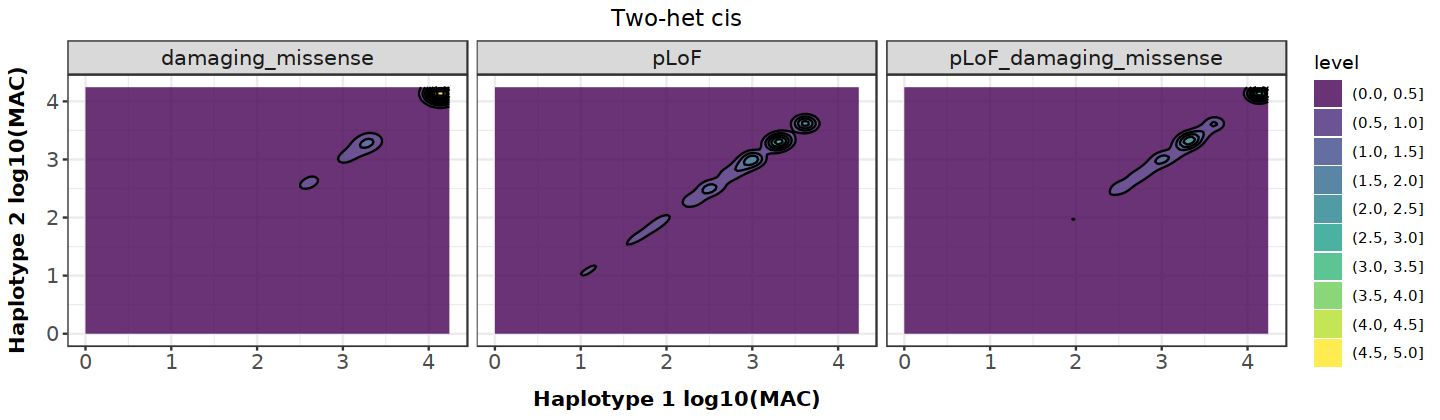

In [132]:
options(repr.plot.width=12, repr.plot.height=3.5)
print(p1)
print(p2)

In [64]:
grepl("fox","the fox crossed the")

[1] TRUE

## 3.4 Compound het exon utilisation

In [ ]:
exon_usage <- do.call(rbind, lapply(full$exon, function(x){
    splitted <- unlist(strsplit(x, split = ';'))
    mut1 <- as.numeric(unlist(strsplit(splitted[1], split = "/")))
    mut2 <- as.numeric(unlist(strsplit(splitted[2], split = "/")))
    total_exons <- mut1[2]
    exon1 <- mut1[1]
    exon2 <- mut2[1]
    return(data.frame(exon1, exon2, total_exons))
}))

In [ ]:
full$exons_between <- abs(full$exon1 - full$exon2)
full$exon1_gene_loc <- full$exon1 / full$total_exons
full$exon2_gene_loc <- full$exon2 / full$total_exons

# 3.0 Geneset comparison

In [348]:
library(MASS) # for glm.nb
library(pscl) # for zinf
library(ggplot2)
library(data.table)

Classes and Methods for R developed in the
Political Science Computational Laboratory
Department of Political Science
Stanford University
Simon Jackman
hurdle and zeroinfl functions by Achim Zeileis



## 3.1 GTEx negative binomial regression

In [9]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")
#other_missense <- read_ukb_wes_kos("other_missense")
#synonymous <- read_ukb_wes_kos("synonymous")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"
#other_missense$annotation <- "other_missense"
#synonymous$annotation <- "synonymous"

In [10]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockouts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 30000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]



In [16]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")

In [17]:
# get transcript lengths and mapping
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]
transcript$norm_length <- (transcript$length-mean(transcript$length))/sd(transcript$length)
transcript$norm_length2 <- transcript$norm_length ^ 2

In [91]:
gtex <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gtex/GTEx.tstat.tsv")
gtex <- cbind(ensembl_gene_id = gtex$ENSGID, apply(gtex[,-1], 2, function(x) x > quantile(x, probs = 0.9)))
colnames(gtex) <- tolower(gsub("_\\s*\\([^\\)]+\\)","",colnames(gtex)))

In [92]:
# categories to merge on
gtex_categories <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gtex/GTEX.tstat.categories.genoppi.csv")
gtex_categories$id <- tolower(gsub("_\\s*\\.[^\\.]+\\.","",gtex_categories$Tissue.genoppi))
gtex_categories$id <- gsub("[0-9]\\.$","",gtex_categories$id)
gtex_categories$id <- gsub("\\.","-",gtex_categories$id)
stopifnot(sum(!gtex_categories$id %in% colnames(gtex)) == 0)


In [20]:
#tolower(gsub("_\\s*\\([^\\)]+\\)","",colnames(gtex)))

In [21]:
# get gnomad geneset and create mapping
gnomad_genesets <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_13_gene_lists.tsv")
gnomad_genesets$hgnc_symbol <- gnomad_genesets$gene
gnomad_genesets$gene <- NULL
geneset_mapping <- tolower(gsub(" ",'_',gnomad_genesets$gene_list))
names(geneset_mapping) <- gnomad_genesets$hgnc_symbol

# get transcript lengths and mapping
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]
transcript$geneset <- geneset_mapping[transcript$hgnc_symbol]

# normalize length
transcript$length <- (transcript$length-mean(transcript$length))/sd(transcript$length)
transcript$length2 <- transcript$length ^ 2

In [22]:
head(transcript$geneset)

[1] NA NA NA NA NA NA

In [23]:
annotations <- c("pLoF_damaging_missense", "pLoF", "damaging_missense", "other_missense", "synonymous")
categories <- colnames(gtex)[-1]

In [103]:
dt <- fread("data/knockouts/tables/combined_annotations_by_sample.nohets.txt.gz")

In [104]:
# aggregate all by chet and cis
full <- dt[dt$is_chet | dt$is_cis, ]
aggr_ko <- aggregate(pKO ~ gene_id + transcript_id + annotation, data = full, FUN=sum)
aggr_full <- aggregate(pKO ~ gene_id + transcript_id + annotation, data = full, FUN=length)
aggr <- merge(aggr_ko, aggr_full, by = c("gene_id","transcript_id", "annotation"))
colnames(aggr) <- c("ensembl_gene_id", "ensembl_transcript_id", "annotation", "n","total")
aggr$subset <- "chet+cis"
aggr_chet_cis <- aggr

# aggregate all by hom and cis
full <- dt[dt$is_hom | dt$is_cis, ]
aggr_ko <- aggregate(pKO ~ gene_id + transcript_id + annotation, data = full, FUN=sum)
aggr_full <- aggregate(pKO ~ gene_id + transcript_id + annotation, data = full, FUN=length)
aggr <- merge(aggr_ko, aggr_full, by = c("gene_id","transcript_id", "annotation"))
colnames(aggr) <- c("ensembl_gene_id", "ensembl_transcript_id", "annotation", "n","total")
aggr$subset <- "hom+cis"
aggr_hom_cis <- aggr

# aggregate all by knockout and cis
full <- dt[dt$is_ko | dt$is_cis, ]
aggr_ko <- aggregate(pKO ~ gene_id + transcript_id + annotation, data = full, FUN=sum)
aggr_full <- aggregate(pKO ~ gene_id + transcript_id + annotation, data = full, FUN=length)
aggr <- merge(aggr_ko, aggr_full, by = c("gene_id","transcript_id", "annotation"))
colnames(aggr) <- c("ensembl_gene_id", "ensembl_transcript_id", "annotation", "n","total")
aggr$subset <- "ko+cis"
aggr_ko_cis <- aggr

# get transcript lengths and mapping
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]
transcript$norm_length <- (transcript$length-mean(transcript$length))/sd(transcript$length)
transcript$norm_length2 <- transcript$norm_length ^ 2

# merge with transcript
combined <- rbind(aggr_chet_cis, aggr_hom_cis, aggr_ko_cis)
merged <- merge(combined, transcript, all.x = TRUE)
stopifnot(nrow(combined) == nrow(merged))

In [106]:
table(merged$annotation)


     damaging_missense         other_missense                   pLoF 
                  6618                  38875                   6156 
pLoF_damaging_missense             synonymous 
                 12833                  31766 

In [93]:
model <- as.formula("n~x+norm_length+norm_length2")
lst_anno <- lapply(annotations, function(anno){
    # subset to right annotaiton
    full <- dt[dt$annotation == anno,]
    lst_data <- list(homzygotes = full[full$subset == "hom+cis",], chets = full[full$subset == "chet+cis"])
    lst_subset <- lapply(names(lst_data), function(dt_name){
        # create subset to be used
        dt_fit <- lst_data[[dt_name]]
        dt_fit <- merge(dt_fit, gtex, by = c("ensembl_gene_id"), all.x = TRUE)
        # iterate through every category
        lst_category <- lapply(categories, function(category){
            print(paste(category, anno, dt_name))
            
            # remove rows that are NA
            na_rows <- rowSums(is.na(dt_fit[,c('n','norm_length','norm_length2')]))
            dt_fit <- dt_fit[!na_rows,]
            dt_fit$x <- dt_fit[[category]]
            
            # set up negative binomial
            x <- glm.nb(model, data = dt_fit, init.theta = 1.041, link = "log")
            fit <- data.frame(coef(summary(x)))
            colnames(fit) <- c("est", "error", "z", "p")

            # get confidence intervals
            conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
            fit$ci_est <- conf[,1]
            fit$ci_lower <- conf[,2]
            fit$ci_upper <- conf[,3]
            fit$keep <- as.logical(c(0, 1, 0, 0))
            fit$id <- category
            fit$annotation <- anno
            fit$subset <- dt_name
            rownames(fit) <- NULL
            return(fit)
        })
        return(do.call(rbind, lst_category))
    })
    return(do.call(rbind, lst_subset))
})
final <- do.call(rbind, lst_anno)

ERROR: Error in merge.data.table(dt_fit, gtex, by = c("ensembl_gene_id"), all.x = TRUE): Elements listed in `by` must be valid column names in x and y


In [24]:
lst_annot <- lapply(annotations, function(anno){
    
    # subset to annotation
    full <- dt[dt$annotation == anno,]
    stopifnot(nrow(full) > 0)
    lst_data <- list(
        homzygotes = full[(full$is_hom | full$is_cis),],
        chets = full[(full$is_chet | full$is_cis),]
    )
    
    # perform analysis
    lst <- lapply(names(lst_data), function(dt_name) {

        print(dt_name)
        print(anno)
        full <- lst_data[[dt_name]]
        print(nrow(full))
        
        # count occurences by gene and merge
        aggr_ko <- aggregate(pKO ~ gene_id + transcript_id, data = full, FUN=sum)
        aggr_full <- aggregate(pKO ~ gene_id + transcript_id, data = full, FUN=length)
        aggr <- merge(aggr_ko, aggr_full, by = c("gene_id","transcript_id"))
        colnames(aggr) <- c("ensembl_gene_id", "ensembl_transcript_id", "n","total")
        print(nrow(aggr))
        
        # get transcript lengths
        mrg <- merge(aggr, transcript, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)
        mrg <- merge(mrg, gtex, by = c("ensembl_gene_id"), all.x = TRUE)

        lst <- lapply(categories, function(category){
            dt_fit <- mrg
            na_rows <- rowSums(is.na(dt_fit[,c('n','length','length2')]))
            dt_fit <- dt_fit[!na_rows,]
            dt_fit$x <- dt_fit[[category]]
            model <- as.formula("n~x+length+length2")
            x <- glm.nb(model, data = dt_fit, init.theta = 1.041, link = "log")
            fit <- data.frame(coef(summary(x)))
            colnames(fit) <- c("est", "error", "z", "p")

            conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
            fit$ci_est <- conf[,1]
            fit$ci_lower <- conf[,2]
            fit$ci_upper <- conf[,3]

            fit$keep <- as.logical(c(0, 1, 0, 0))
            fit$id <- category
            rownames(fit) <- NULL
            return(fit)
        })

        out <- do.call(rbind, lst)
        out$subset <- dt_name
        out$annotation <- anno
        return(out)
    })
    
    return(do.call(rbind, lst))
})




[1] "homzygotes"
[1] "pLoF_damaging_missense"
[1] 99831
[1] 4209
[1] "chets"
[1] "pLoF_damaging_missense"
[1] 92288
[1] 3846
[1] "homzygotes"
[1] "pLoF"
[1] 42575
[1] 2148
[1] "chets"
[1] "pLoF"
[1] 35500
[1] 1721


In [121]:
fits <- do.call(rbind, lst)
fits <- fits[fits$keep == 1, ]
fits <- merge(fits, gtex_categories, all.x = TRUE)
#fits$category <- "damaging_missense"
#fits_damaging_missense <- fits

In [67]:
final <- final[final$keep==1,]
fits <- merge(final, gtex_categories, all.x = TRUE)
fits <- fits[(fits$annotation == "pLoF"),]

In [68]:
order_df <- fits[fits$annotation == "chets",]
fits$id <- factor(fits$id, levels = unique(fits$id[order(fits$est)]))

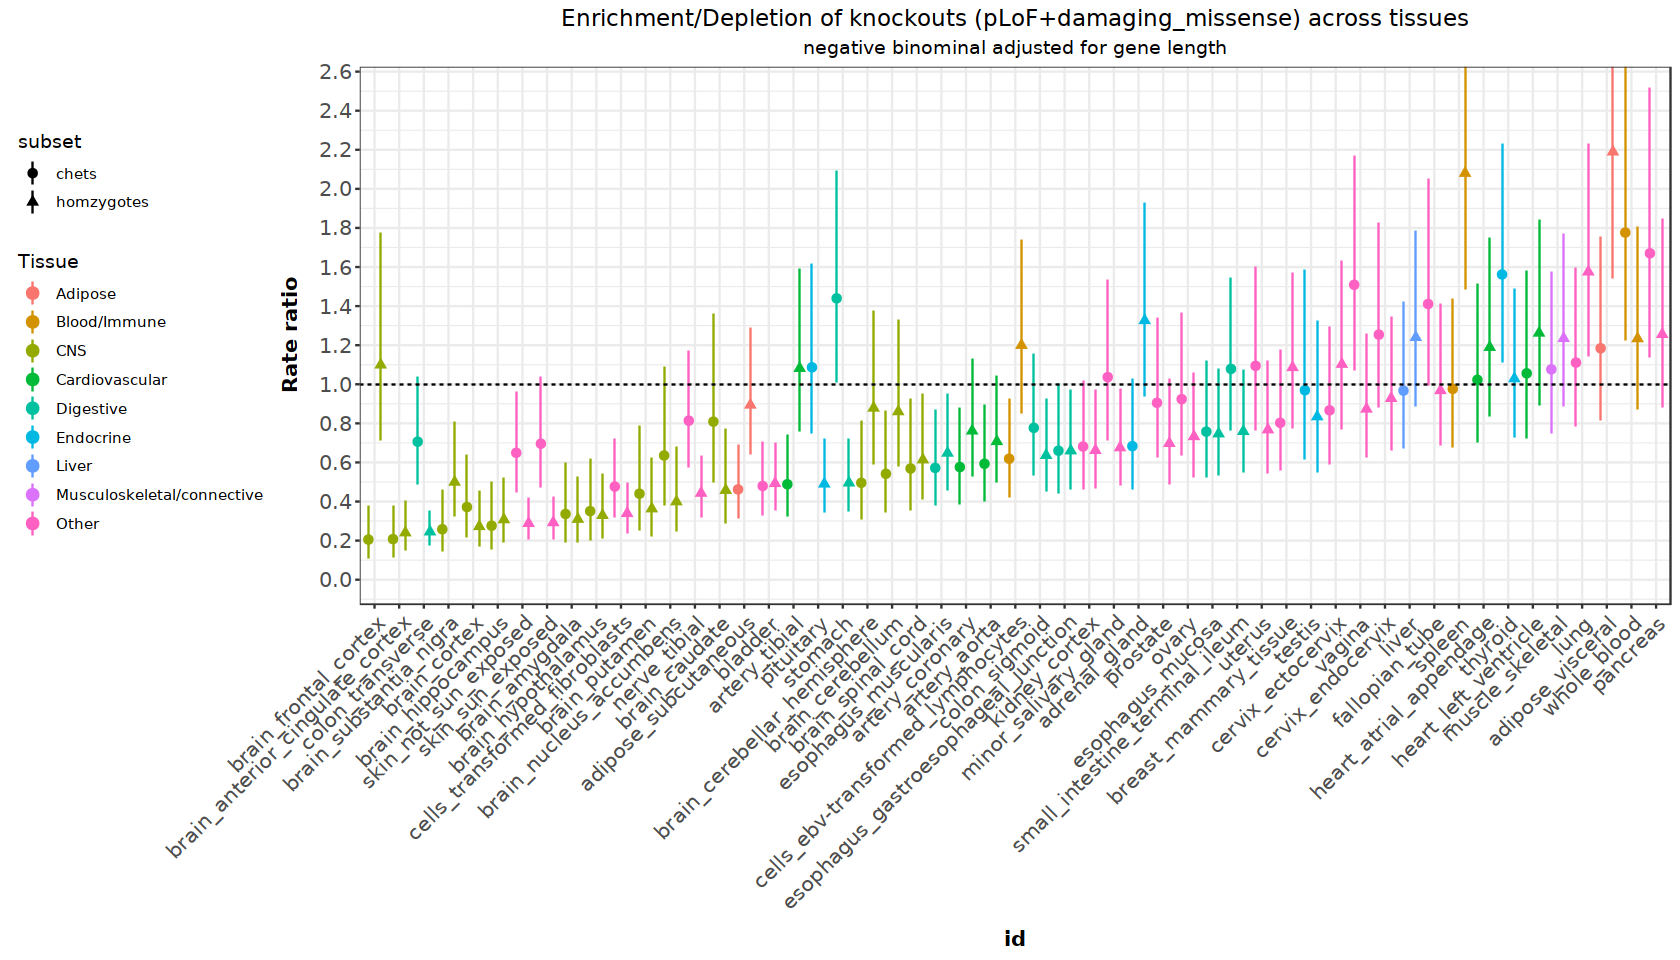

In [69]:
options(repr.plot.width=14, repr.plot.height=8)
title <- "Enrichment/Depletion of knockouts (pLoF+damaging_missense) across tissues"
subtitle <- "negative binominal adjusted for gene length"
pd <- position_dodge(1)
ggplot(fits, aes(x=id, y=ci_est, ymin=ci_lower, ymax=ci_upper, color=Tissue.category.for.display, 
                 group=subset, shape=subset)) +
    geom_pointrange(position = pd) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    ggtitle(title, subtitle) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    coord_cartesian(ylim = c(0,2.5)) +
    labs(color = "Tissue") +
    theme_bw() +
    ylab("Rate ratio") +
        theme(
        legend.position = "left",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 45, hjust = 0.99, vjust = 0.99),
    ) 

#ggplot(fits, aes(y=id, x=est_exp, xmin=est-error, xmax=est+error, color=Tissue.category.for.display)) +

In [542]:
order_df <- aggregate(ci_est ~ Tissue.category.for.display,data = fits, FUN = mean)
colnames(order_df) <- c("tissue","est")
fits$Tissue.category.for.display <- factor(fits$Tissue.category.for.display, levels = order_df$tissue[rev(order(order_df$est))])

In [543]:
my_colors <- brewer.pal(9, "Reds")
names(my_colors) <- order_df$tissue[rev(order(order_df$est))]

In [544]:
fill_scale <- scale_fill_manual(name = "Tissue.category.for.display", values = my_colors)
color_scale <- scale_color_manual(name = "Tissue.category.for.display", values = my_colors)

In [550]:
table(fits$Tissue.category.for.display)


Musculoskeletal/connective                      Liver 
                         2                          2 
              Blood/Immune                    Adipose 
                         6                          4 
                     Other             Cardiovascular 
                        34                         10 
                 Endocrine                  Digestive 
                         8                         14 
                       CNS 
                        26 

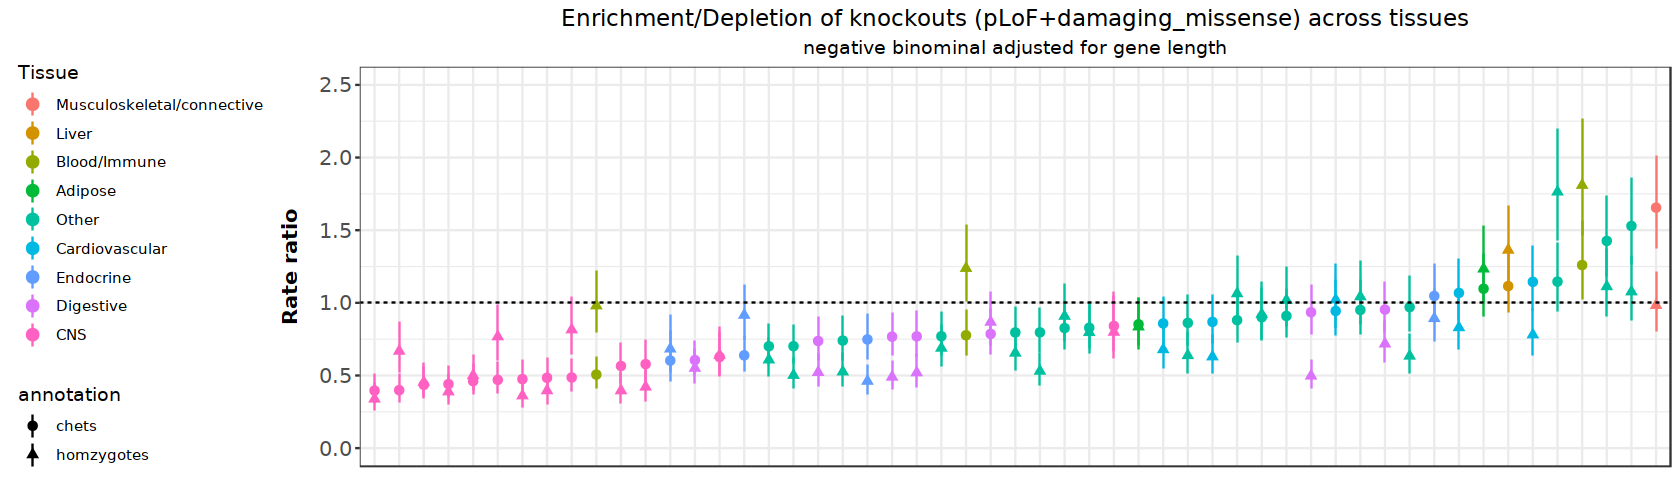

In [546]:
options(repr.plot.width=14, repr.plot.height=4)
title <- "Enrichment/Depletion of knockouts (pLoF+damaging_missense) across tissues"
subtitle <- "negative binominal adjusted for gene length"
pd <- position_dodge(0)
ggplot(fits, aes(x=id, y=ci_est, ymin=ci_lower, ymax=ci_upper, color=Tissue.category.for.display, 
                 group=annotation, shape=annotation)) +
    geom_pointrange(position = pd) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    ggtitle(title, subtitle) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=8)) +
    coord_cartesian(ylim = c(0,2.5)) +
    labs(color = "Tissue") +
    theme_bw() +
    ylab("Rate ratio") +
        theme(
        legend.position = "left",
        strip.text = element_text(size=12),
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        #axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        #axis.text.x = element_text(angle = 45, hjust = 0.99, vjust = 0.99),
        axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank()
    ) 

#ggplot(fits, aes(y=id, x=est_exp, xmin=est-error, xmax=est+error, color=Tissue.category.for.display)) +

In [370]:
d1 <- lst[[1]]
d1 <- d1[d1$keep == 1, ]
d2 <- lst[[2]]
d2 <- d2[d2$keep == 1, ]
colnames(d1)[1:8] <- paste0("hom_",colnames(d1)[1:8])
colnames(d2)[1:8] <- paste0("chet_",colnames(d2)[1:8])
d <- merge(d1, d2, by = "id")
d <- merge(d, gtex_categories, all.x = TRUE)

In [371]:
set.seed(4)
sig <- 0.05/nrow(d)
d$significant <- d$hom_p < sig | d$chet_p < sig
d$to_label <- (d$id %in% sample(d$id[d$significant], size = 8))
d$label <- NA
d$label[d$to_label] <- d$Tissue[d$to_label]

Warning message:
"Removed 45 rows containing missing values (geom_text_repel)."


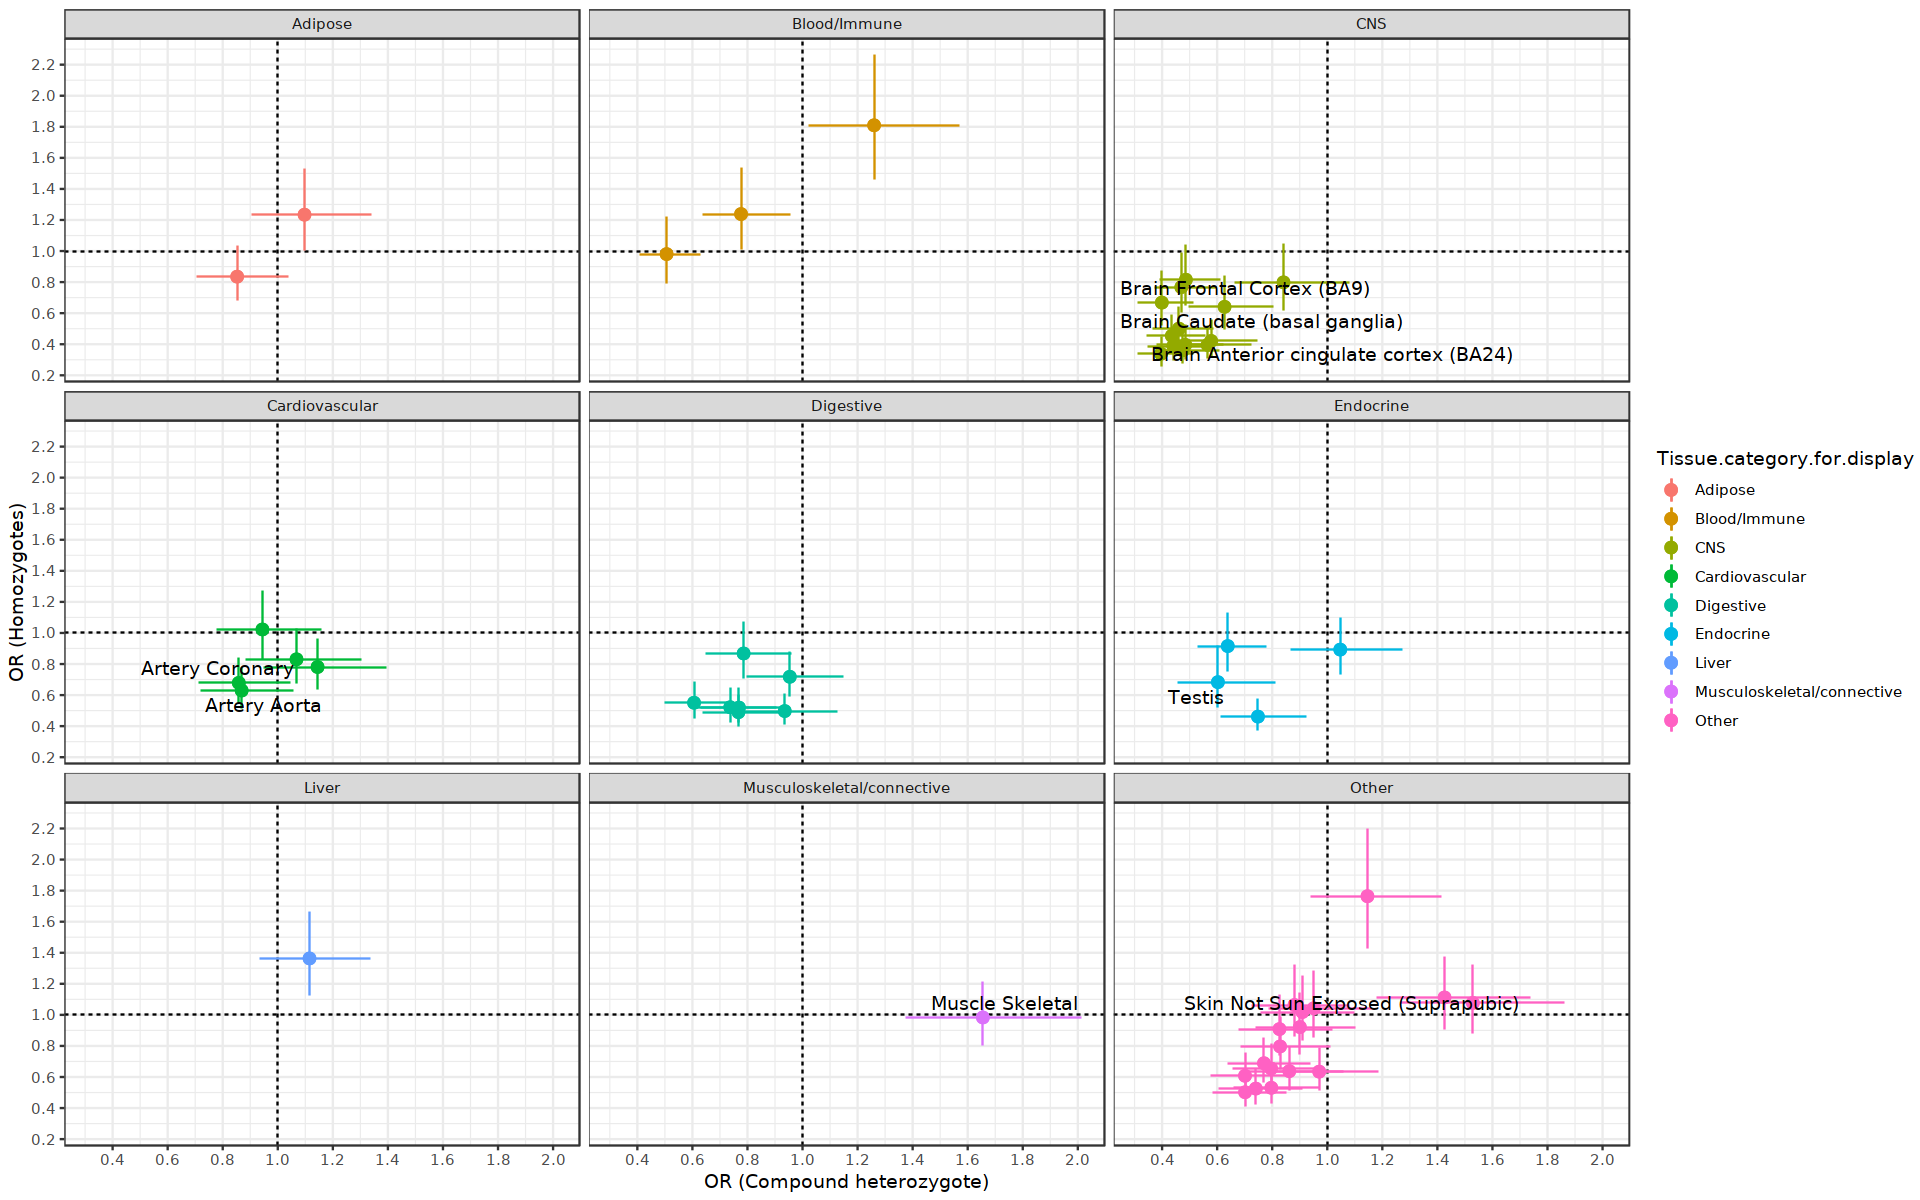

In [372]:
options(repr.plot.width=16, repr.plot.height=10)
ggplot(d, aes(
             y=hom_ci_est, #ymin=hom_ci_lower, ymax=hom_ci_upper, 
             x=chet_ci_est,# xmin=chet_ci_lower, xmax=chet_ci_upper, 
             color=Tissue.category.for.display,
             label=label
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    geom_vline(xintercept = 1, linetype = 'dashed') +
    #coord_cartesian(xlim = c(0,2), ylim=c(0,2)) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab("OR (Compound heterozygote)") + 
    ylab("OR (Homozygotes)") +
    theme_bw() +
    geom_pointrange(aes(xmin=chet_ci_lower, xmax=chet_ci_upper)) +
    geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    geom_point(size = 2) +
    geom_text_repel(color = 'black') + 
    facet_wrap(~Tissue.category.for.display)

### 3.1 Modelling by gene P-value bins

In [49]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [50]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense, other_missense, synonymous))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

ERROR: Error in lapply(list(...), function(x) if (is.list(x)) x else as.data.table(x)): object 'other_missense' not found


## 3.2 Modelling by REACTOME

In [5]:
library(genoppi)

Loading required package: hash

hash-2.2.6.1 provided by Decision Patterns



Attaching package: 'hash'


The following object is masked from 'package:data.table':

    copy


Loading required package: shiny

Loading required package: shinydashboard


Attaching package: 'shinydashboard'


The following object is masked from 'package:graphics':

    box


Loading required package: plotly


Attaching package: 'plotly'


The following object is masked from 'package:MASS':

    select


The following object is masked from 'package:ggplot2':

    last_plot


The following object is masked from 'package:stats':

    filter


The following object is masked from 'package:graphics':

    layout




In [10]:
# mapping bridge
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
hgnc_to_ensembl <- bridge$ensembl_gene_id
names(hgnc_to_ensembl) <- bridge$hgnc_symbol

In [7]:
# set up kegg
kegg <- msigdb_c2_table[grepl('KEGG', msigdb_c2_table$Set.name),]
colnames(kegg) <- c("hgnc_symbol", "geneset")
kegg$ensembl_gene_id <- hgnc_to_ensembl[kegg$hgnc_symbol]
rownames(kegg) <- NULL

# set up reactome
reactome <- msigdb_c2_table[grepl("REACTOME", msigdb_c2_table$Set.name),]
colnames(reactome) <- c("hgnc_symbol", "geneset")
reactome$ensembl_gene_id <- hgnc_to_ensembl[reactome$hgnc_symbol]
rownames(reactome) <- NULL

# combine
geneset <- rbind(kegg, reactome)

In [8]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [9]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

# rename for easier downstream
colnames(dt)[colnames(dt) == "gene_id"] <- "ensembl_gene_id"
colnames(dt)[colnames(dt) == "transcript_id"] <- "ensembl_transcript_id"

In [39]:
transcript_canonical <- unique(dt$ensembl_transcript_id)
categories <- unique(na.omit(geneset_with_transcript$geneset))[25:30]
annotations <- c("pLoF") #,"damaging_missense","pLoF_damaging_missense")

In [40]:
# get transcript lengths and subset to canonical transcripts
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]
geneset_with_transcript <- merge(geneset, transcript)
geneset_with_transcript <- geneset_with_transcript[geneset_with_transcript$ensembl_transcript_id %in% transcript_canonical,]

# normalize length
geneset_with_transcript$length <- (geneset_with_transcript$length-mean(geneset_with_transcript$length))/sd(geneset_with_transcript$length)
geneset_with_transcript$length2 <- geneset_with_transcript$length ^ 2


In [47]:
# subset main data and get homs/cis
dt_subset <- dt[dt$annotation == "pLoF",]
lst_data <- list(
homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),],
chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
)

full <- lst_data$homzygotes
aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
mrg <- merge(aggr, geneset_with_transcript, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)

category <- categories[1]
print(category)
dt_fit <- mrg

na_rows <- rowSums(is.na(dt_fit[,c('n','length','length2')]))
dt_fit <- dt_fit[!na_rows,]

dt_fit$x <- FALSE
dt_fit$x[dt_fit$geneset == category] <- TRUE

print(sum(dt_fit$x))
model <- as.formula("n~x+length+length2")
fit <- glm.nb(model, data = dt_fit, init.theta = 1.041, link = "log") #
colnames(fit) <- c("est", "error", "z", "p")


[1] "REACTOME_ANTIVIRAL_MECHANISM_BY_IFN_STIMULATED_GENES"
[1] 5


ERROR: Error in `colnames<-`(`*tmp*`, value = c("est", "error", "z", "p")): attempt to set 'colnames' on an object with less than two dimensions


In [41]:
outer_list <- lapply(annotations, function(anno){
    
    print(anno)
    
    # subset main data and get homs/cis
    dt_subset <- dt[dt$annotation == anno,]
    lst_data <- list(
        homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),],
        chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
    )

    # get OR/P-values for each dataset
    lst <- lapply(names(lst_data), function(dt_name) {

        full <- lst_data[[dt_name]]
        aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
        aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
        aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
        colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
        mrg <- merge(aggr, geneset_with_transcript, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)
        
        lst <- lapply(categories, function(category){
            print(category)
            dt_fit <- mrg
            
            na_rows <- rowSums(is.na(dt_fit[,c('n','length','length2')]))
            dt_fit <- dt_fit[!na_rows,]
            
            dt_fit$x <- FALSE
            dt_fit$x[dt_fit$geneset == category] <- TRUE
            if (sum(dt_fit$x) > 1){
                
                print(sum(dt_fit$x))
                model <- as.formula("n~x+length+length2")
                x <- glm.nb(model, data = dt_fit, init.theta = 1.041, link = "log") #
                colnames(fit) <- c("est", "error", "z", "p")

                conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
                fit$ci_est <- conf[,1]
                fit$ci_lower <- conf[,2]
                fit$ci_upper <- conf[,3]
                fit$keep <- as.logical(c(0, 1, 0, 0))
                fit$id <- category
                rownames(fit) <- NULL
                
                fit <- fit[fit$keep]
                fit$n_genes <- sum()
                
                return(fit) 
            }

        })

        out <- do.call(rbind, lst)
        out$dt_name <- dt_name
        return(out)
    })

    # combine the data into a single data.frame
    d1 <- lst[[1]]
    d1 <- d1[d1$keep == 1, ]
    d2 <- lst[[2]]
    d2 <- d2[d2$keep == 1, ]
    colnames(d1)[1:8] <- paste0("hom_",colnames(d1)[1:8])
    colnames(d2)[1:8] <- paste0("chet_",colnames(d2)[1:8])
    d <- merge(d1, d2, by = "id")
    d$annotation <- anno
    
    return(d)
})

[1] "pLoF"
[1] "REACTOME_ANTIVIRAL_MECHANISM_BY_IFN_STIMULATED_GENES"
[1] 5
[1] "REACTOME_CELL_CYCLE"
[1] 49
[1] "REACTOME_HCMV_EARLY_EVENTS"
[1] 5
[1] "REACTOME_TRANSPORT_OF_MATURE_TRANSCRIPT_TO_CYTOPLASM"
[1] 3
[1] "REACTOME_GLUCOSE_METABOLISM"
[1] 8
[1] "REACTOME_INFLUENZA_INFECTION"
[1] 4
[1] "REACTOME_ANTIVIRAL_MECHANISM_BY_IFN_STIMULATED_GENES"
[1] 4
[1] "REACTOME_CELL_CYCLE"
[1] 42
[1] "REACTOME_HCMV_EARLY_EVENTS"
[1] 3


ERROR: Error: no valid set of coefficients has been found: please supply starting values


### 3.2 Modelling by LOEUF

In [3]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")
synonymous <- read_ukb_wes_kos("synoymous")
other_missense <- read_ukb_wes_kos("other_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"
synonymous$annotation <- "synonymous"
other_missense$annotation <- "other_missense"

In [374]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense, synonymous, other_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

# rename for easier downstream
colnames(dt)[colnames(dt) == "gene_id"] <- "ensembl_gene_id"
colnames(dt)[colnames(dt) == "transcript_id"] <- "ensembl_transcript_id"

In [375]:
# get gnomad geneset and create mapping
gnomad_genesets <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv")
gnomad_genesets <- gnomad_genesets[gnomad_genesets$canonical,]
cols_to_keep <- c('gene','gene_id','transcript','oe_lof_upper_bin','oe_lof_upper')
gnomad_genesets <- gnomad_genesets[,colnames(gnomad_genesets) %in% cols_to_keep, with = FALSE]
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "gene_id"] <- "ensembl_gene_id"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "gene"] <- "hgnc_symbol"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "transcript"] <- "ensembl_transcript_id"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "oe_lof_upper"] <- "loeuf"


In [376]:
# get transcript lengths and mapping
transcript <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221216_enstid_ensgid_lengths.txt.gz")
transcript <- transcript[,c("ensembl_gene_id", "ensembl_transcript_id", "hgnc_symbol", "chromosome_name", "length")]

# normalize length
transcript$length <- (transcript$length-mean(transcript$length))/sd(transcript$length)
transcript$length2 <- transcript$length ^ 2
geneset <- merge(gnomad_genesets, transcript, by = c("ensembl_gene_id", "ensembl_transcript_id"))

In [377]:
categories <- unique(na.omit(geneset$oe_lof_upper_bin))
annotations <- c("pLoF","damaging_missense","pLoF_damaging_missense")

In [378]:
outer_list <- lapply(annotations, function(anno){
    
    # subset main data and get homs/cis
    dt_subset <- dt[dt$annotation == anno,]
    lst_data <- list(
        homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),],
        chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
    )

    # get OR/P-values for each dataset
    lst <- lapply(names(lst_data), function(dt_name) {

        print(dt_name)
        full <- lst_data[[dt_name]]
        aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
        aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
        aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
        colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
        mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)

        lst <- lapply(categories, function(category){
            dt_fit <- mrg
            na_rows <- rowSums(is.na(dt_fit[,c('n','length','length2')]))
            dt_fit <- dt_fit[!na_rows,]

            dt_fit$x <- FALSE
            dt_fit$x[dt_fit$oe_lof_upper_bin == category] <- TRUE

            model <- as.formula("n~x+length+length2")
            x <- glm.nb(model, data = dt_fit, init.theta = 1.041, link = "log") #
            fit <- data.frame(coef(summary(x)))
            colnames(fit) <- c("est", "error", "z", "p")

            conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
            fit$ci_est <- conf[,1]
            fit$ci_lower <- conf[,2]
            fit$ci_upper <- conf[,3]

            fit$keep <- as.logical(c(0, 1, 0, 0))
            fit$id <- category
            rownames(fit) <- NULL
            return(fit)
        })

        out <- do.call(rbind, lst)
        out$dt_name <- dt_name
        return(out)
    })

    # combine the data into a single data.frame
    d1 <- lst[[1]]
    d1 <- d1[d1$keep == 1, ]
    d2 <- lst[[2]]
    d2 <- d2[d2$keep == 1, ]
    colnames(d1)[1:8] <- paste0("hom_",colnames(d1)[1:8])
    colnames(d2)[1:8] <- paste0("chet_",colnames(d2)[1:8])
    d <- merge(d1, d2, by = "id")
    d$annotation <- anno
    
    return(d)
})

[1] "homzygotes"
[1] "chets"
[1] "homzygotes"
[1] "chets"
[1] "homzygotes"
[1] "chets"


In [401]:
d <- do.call(rbind, outer_list)
ids <- sort(unique(d$id))
d$loeuf <- factor(unlist(lapply(ids, function(id) paste0(id,'-',id+1))))


In [402]:
colfunc <- colorRampPalette(c("tomato2", "lightblue"))

In [403]:
my_colors <- colfunc(length(unique(d$id)))
names(my_colors) <- levels(d$loeuf)
fill_scale <- scale_fill_manual(name = "loeuf", values = my_colors)
color_scale <- scale_color_manual(name = "loeuf", values = my_colors)

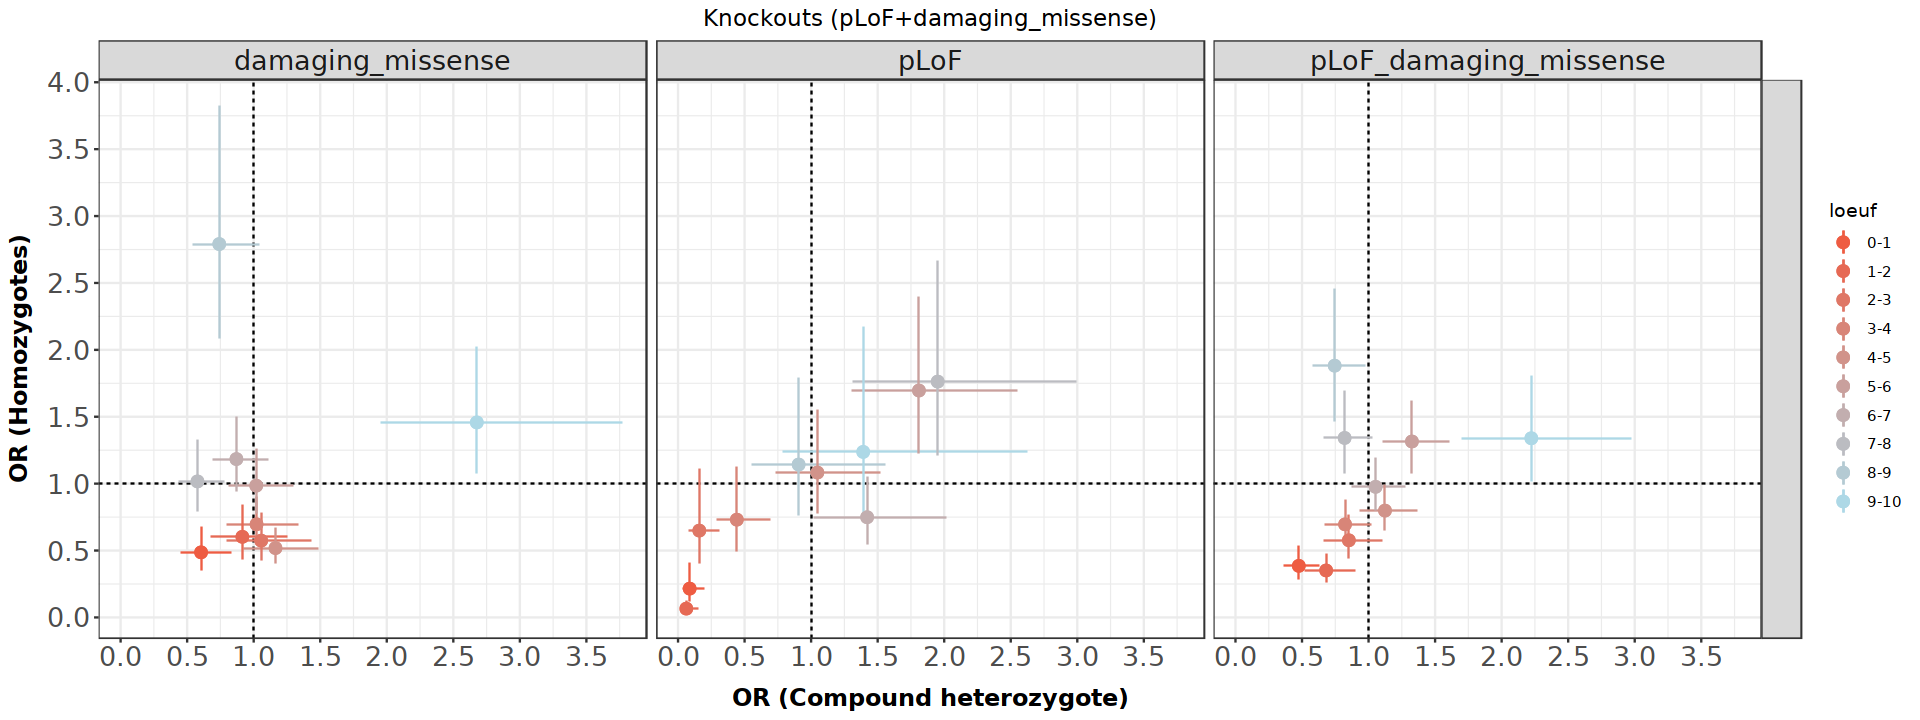

In [404]:
options(repr.plot.width=16, repr.plot.height=6)
ggplot(d, aes(
             y=hom_ci_est, #ymin=hom_ci_lower, ymax=hom_ci_upper, 
             x=chet_ci_est,# xmin=chet_ci_lower, xmax=chet_ci_upper, 
             color=loeuf
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=9)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=9)) +
    xlab("OR (Compound heterozygote)") + 
    ylab("OR (Homozygotes)") +
    color_scale + 
    theme_bw() +
    geom_pointrange(aes(xmin=chet_ci_lower, xmax=chet_ci_upper)) +
    geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    #ggtitle("Knockout depletion (pLoF+damaging_missense)") +
    ggtitle("Knockouts (pLoF+damaging_missense)") +
    geom_point(size = 2) +
        theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank()
    ) +
    facet_grid(""~annotation)

### 3.2.1 Nice plotting by LOEUF

In [416]:
outer_list <- lapply(annotations, function(anno){
    
    # subset main data and get homs/cis
    dt_subset <- dt[dt$annotation == anno,]
    lst_data <- list(
        homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),],
        chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
    )

    # get OR/P-values for each dataset
    lst <- lapply(names(lst_data), function(dt_name) {

        print(dt_name)
        full <- lst_data[[dt_name]]
        aggr_ko <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
        aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
        aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
        colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
        mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)

        lst <- lapply(categories, function(category){
            dt_fit <- mrg
            na_rows <- rowSums(is.na(dt_fit[,c('n','length','length2')]))
            dt_fit <- dt_fit[!na_rows,]

            dt_fit$x <- FALSE
            dt_fit$x[dt_fit$oe_lof_upper_bin == category] <- TRUE

            model <- as.formula("n~x+length+length2")
            x <- glm.nb(model, data = dt_fit, init.theta = 1.041, link = "log") #
            fit <- data.frame(coef(summary(x)))
            colnames(fit) <- c("est", "error", "z", "p")

            conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
            fit$ci_est <- conf[,1]
            fit$ci_lower <- conf[,2]
            fit$ci_upper <- conf[,3]

            fit$keep <- as.logical(c(0, 1, 0, 0))
            fit$id <- category
            rownames(fit) <- NULL
            return(fit)
        })

        out <- do.call(rbind, lst)
        out$dt_name <- dt_name
        return(out)
    })

    # combine the data into a single data.frame
    d1 <- lst[[1]]
    d1 <- d1[d1$keep == 1, ]
    d2 <- lst[[2]]
    d2 <- d2[d2$keep == 1, ]
    d <- rbind(d1, d2)
    d$annotation <- anno
    return(d)
})

[1] "homzygotes"
[1] "chets"
[1] "homzygotes"
[1] "chets"
[1] "homzygotes"
[1] "chets"


In [432]:
d <- do.call(rbind, outer_list)
ids <- sort(unique(d$id))
d$loeuf <- factor(unlist(lapply(d$id, function(id) paste0(id,'-',id+1))))

In [433]:
head(d, n = 2)

,est,error,z,p,ci_est,ci_lower,ci_upper,keep,id,dt_name,annotation,loeuf
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<chr>,<chr>,<fct>
2,0.07955466,0.1782389,0.4463373,6.553536e-01,1.08280474,0.77342658,1.5578532,TRUE,4,homzygotes,pLoF,4-5
6,-2.72109198,0.3216602,-8.4595233,2.684728e-17,0.06580286,0.03561064,0.1252358,TRUE,1,homzygotes,pLoF,1-2


In [441]:
categories <- levels(d$annotation)
my_colors <- c("#DD686D","#B13F64", "#F09D7C")
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "annotation", values = my_colors)
color_scale <- scale_color_manual(name = "annotation", values = my_colors)

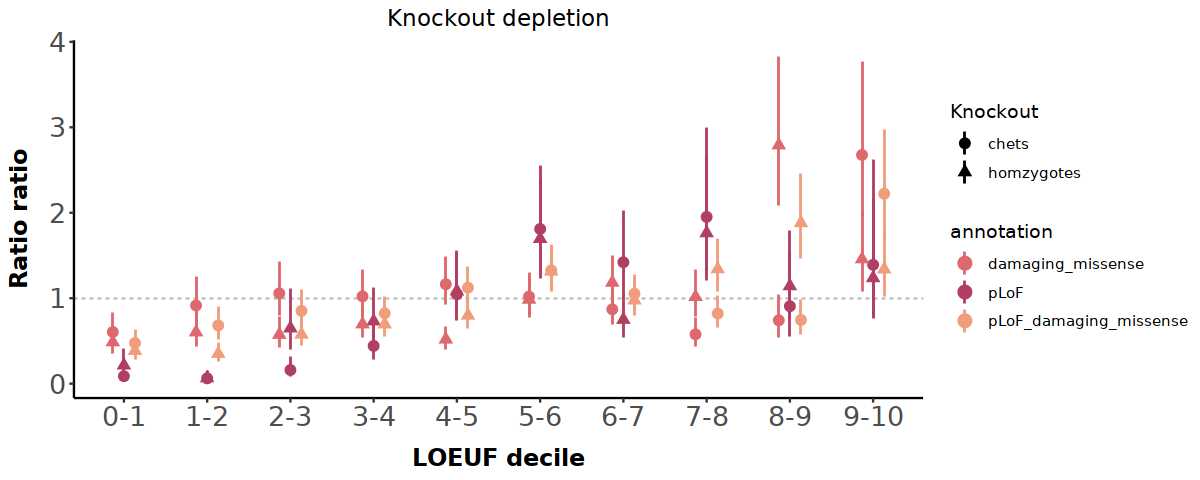

In [472]:
options(repr.plot.width=10, repr.plot.height=4)
pd <- position_dodge(0.4)
ggplot(d, aes(
             x=loeuf,
             y=ci_est, ymin=ci_lower, ymax=ci_upper, 
             color=annotation,
             group=annotation,
             shape=dt_name
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed', color = "grey") +
    geom_pointrange(position = pd, size = 0.6) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    #coord_cartesian(ylim=c(0, 3)) +
    xlab("LOEUF decile") + 
    ylab("Ratio ratio") +
    color_scale + 
    theme_classic() +
    labs(shape="Knockout", color = "Annotation") +
    ggtitle("Knockout depletion") +
        theme(
        legend.position = "right",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank(),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank()
    ) 


In [ ]:
options(repr.plot.width=16, repr.plot.height=6)
ggplot(d, aes(
             y=hom_ci_est, #ymin=hom_ci_lower, ymax=hom_ci_upper, 
             x=chet_ci_est,# xmin=chet_ci_lower, xmax=chet_ci_upper, 
             color=loeuf
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=9)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=9)) +
    xlab("OR (Compound heterozygote)") + 
    ylab("OR (Homozygotes)") +
    color_scale + 
    theme_bw() +
    geom_pointrange(aes(xmin=chet_ci_lower, xmax=chet_ci_upper)) +
    geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    #ggtitle("Knockout depletion (pLoF+damaging_missense)") +
    ggtitle("Knockouts (pLoF+damaging_missense)") +
    geom_point(size = 2) +
        theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank()
    ) +
    facet_grid(""~annotation)

### 3.2 Modelling two-het cis by LOEUF

In [176]:
dt_subset <- dt[dt$annotation == "pLoF_damaging_missense",]
lst_data <- list(
    homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),],
    chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
)

In [177]:
lst <- lapply(names(lst_data), function(dt_name) {
    
    print(dt_name)
    full <- lst_data[[dt_name]]
    aggr_ko <- aggregate(is_cis ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=sum)
    aggr_full <- aggregate(pKO ~ ensembl_gene_id + ensembl_transcript_id, data = full, FUN=length)
    aggr <- merge(aggr_ko, aggr_full, by = c("ensembl_gene_id","ensembl_transcript_id"))
    colnames(aggr) <- c("ensembl_gene_id","ensembl_transcript_id", "n","total")
    mrg <- merge(aggr, geneset, by = c("ensembl_gene_id", "ensembl_transcript_id"), all.x = TRUE)
    
    lst <- lapply(categories, function(category){
        dt_fit <- mrg
        na_rows <- rowSums(is.na(dt_fit[,c('n','length','length2')]))
        dt_fit <- dt_fit[!na_rows,]
        
        dt_fit$x <- FALSE
        dt_fit$x[dt_fit$oe_lof_upper_bin == category] <- TRUE
        
        model <- as.formula("n~x+length+length2")
        x <- glm.nb(model, data = dt_fit, init.theta = 1.041, link = "log") #
        fit <- data.frame(coef(summary(x)))
        colnames(fit) <- c("est", "error", "z", "p")

        conf <- suppressMessages(exp(cbind(coef(x), confint(x))))
        fit$ci_est <- conf[,1]
        fit$ci_lower <- conf[,2]
        fit$ci_upper <- conf[,3]
        
        #model <- as.formula("n~x+length+length2|1")
        #x <- zeroinfl(model, data = dt_fit)
        #fit <- data.frame(summary(x)[[1]]$count)
        #colnames(fit) <- c("est", "error", "z", "p")

        #conf <- suppressMessages(exp(cbind(fit[,1], confint(x)[1:4,])))
        #fit$ci_est <- conf[,1]
        #fit$ci_lower <- conf[,2]
        #fit$ci_upper <- conf[,3]
        
        fit$keep <- as.logical(c(0, 1, 0, 0))
        fit$id <- category
        rownames(fit) <- NULL
        return(fit)
    })
    
    out <- do.call(rbind, lst)
    out$annotation <- dt_name
    return(out)
})

[1] "homzygotes"


Warning message:
"glm.fit: algorithm did not converge"
Warning message:
"glm.fit: algorithm did not converge"


[1] "chets"


Warning message:
"glm.fit: algorithm did not converge"


In [179]:
d1 <- lst[[1]]
d1 <- d1[d1$keep == 1, ]
d2 <- lst[[2]]
d2 <- d2[d2$keep == 1, ]
colnames(d1)[1:8] <- paste0("hom_",colnames(d1)[1:8])
colnames(d2)[1:8] <- paste0("chet_",colnames(d2)[1:8])
d <- merge(d1, d2, by = "id")

In [180]:
#d$id <- factor(as.character(d$id), levels <- as.character(0:9))
ids <- sort(unique(d$id))
d$loeuf <- factor(unlist(lapply(ids, function(id) paste0(id,'-',id+1))))


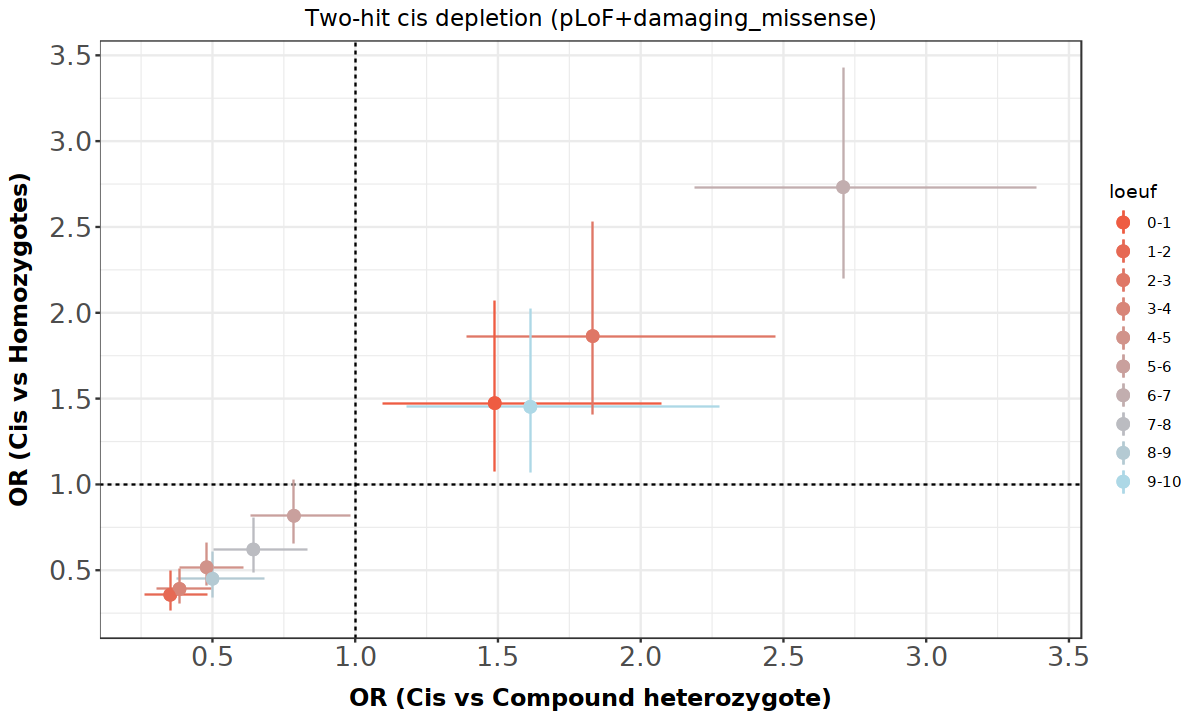

In [182]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(d, aes(
             y=hom_ci_est, #ymin=hom_ci_lower, ymax=hom_ci_upper, 
             x=chet_ci_est,# xmin=chet_ci_lower, xmax=chet_ci_upper, 
             color=loeuf
            )
      ) +
    geom_hline(yintercept = 1, linetype = 'dashed') +
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=9)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=9)) +
    xlab("OR (Cis vs Compound heterozygote)") + 
    ylab("OR (Cis vs Homozygotes)") +
    color_scale + 
    theme_bw() +
    geom_pointrange(aes(xmin=chet_ci_lower, xmax=chet_ci_upper)) +
    geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    #ggtitle("Knockout depletion (pLoF+damaging_missense)") +
    ggtitle("Two-hit cis depletion (pLoF+damaging_missense)") +
    geom_point(size = 2) +
        theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank()
    ) 

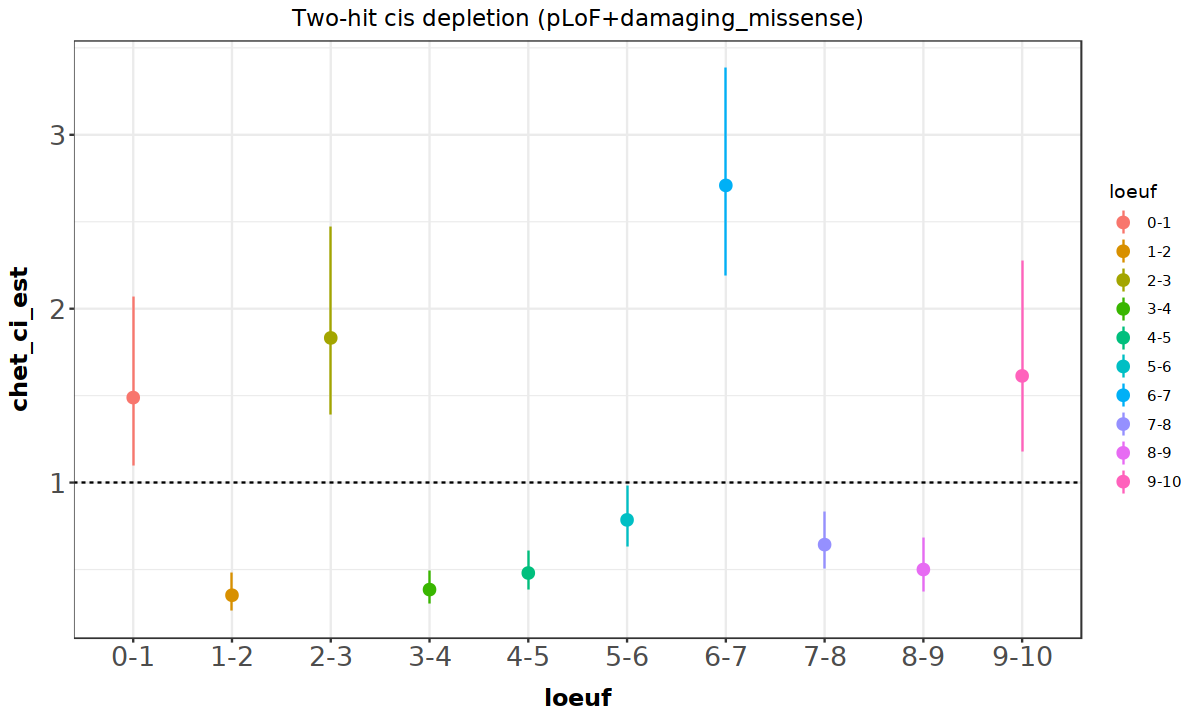

In [324]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(d, aes(
             y=chet_ci_est,
             x=loeuf,
             color=loeuf
            )
      ) +
    
    geom_hline(yintercept = 1, linetype = 'dashed') +
    #geom_vline(xintercept = 1, linetype = 'dashed') +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=9)) +
    #scale_y_continuous(breaks=scales::pretty_breaks(n=9)) +
    #xlab("OR (Compound heterozygote)") + 
    #ylab("OR (Homozygotes)") +
    fill_scale + 
    theme_bw() +
    geom_pointrange(aes(ymin=chet_ci_lower, ymax=chet_ci_upper)) +
    #geom_pointrange(aes(ymin=hom_ci_lower, ymax=hom_ci_upper)) +
    #ggtitle("Knockout depletion (pLoF+damaging_missense)") +
    ggtitle("Two-hit cis depletion (pLoF+damaging_missense)") +
        theme(
        legend.position = "right",
        strip.text = element_text(size=16),
        axis.text=element_text(size=16),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        panel.background = element_blank()
    )

## 3.3 Logistic regression for phenotype enrichment

In [5]:
# retrive them
pLoF <- read_ukb_wes_kos("pLoF")
damaging_missense <- read_ukb_wes_kos("damaging_missense")
pLoF_damaging_missense <- read_ukb_wes_kos("pLoF_damaging_missense")

# annotate
pLoF$annotation <- "pLoF"
damaging_missense$annotation <- "damaging_missense"
pLoF_damaging_missense$annotation <- "pLoF_damaging_missense"

In [6]:
# keep only relevant columns
cols_to_keep <- c("gene_id","s","knockout","annotation", "pKO", "chromosome", "transcript_id")
dt <- setDT(rbind(pLoF, damaging_missense, pLoF_damaging_missense))
dt <- dt[!(dt$knockout %in% "Heterozygote"), ]
dt <- dt[,colnames(dt) %in% cols_to_keep, with = FALSE]

# format
dt$is_chet <- dt$knockout %in% "Compound heterozygote"
dt$is_cis <- dt$knockout %in% "Compound heterozygote (cis)"
dt$is_hom <- dt$knockout %in% "Homozygote"
dt$is_ko <- dt$is_hom | dt$is_chet
dt$knockout <- NULL

# exclude common knockoiuts
counts <- data.table(table(dt$is_ko, dt$gene_id))
counts <- counts[counts$V1 == TRUE,]
counts <- counts[rev(order(counts$N))]
gene_id_exclude <- counts$V2[counts$N > 10000]
dt <- dt[!(dt$gene_id %in% gene_id_exclude),]

# rename for easier downstream
colnames(dt)[colnames(dt) == "gene_id"] <- "ensembl_gene_id"
colnames(dt)[colnames(dt) == "transcript_id"] <- "ensembl_transcript_id"

In [46]:
# get gnomad geneset and create mapping
gnomad_genesets <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_11_full_constraint_metrics.tsv")
gnomad_genesets <- gnomad_genesets[gnomad_genesets$canonical,]
cols_to_keep <- c('gene','gene_id','transcript','oe_lof_upper_bin','oe_lof_upper', "pLI")
gnomad_genesets <- gnomad_genesets[,colnames(gnomad_genesets) %in% cols_to_keep, with = FALSE]
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "gene_id"] <- "ensembl_gene_id"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "gene"] <- "hgnc_symbol"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "transcript"] <- "ensembl_transcript_id"
colnames(gnomad_genesets)[colnames(gnomad_genesets) == "oe_lof_upper"] <- "loeuf"
gnomad_genesets$pLI_cutoff <- gnomad_genesets$pLI >= 0.9

In [99]:
# load phenotypes
icd <- fread("/well/lindgren-ukbb/projects/ukbb-11867/samvida/general_resources/UKB_codelists/chronological-map-phenotypes/annot_dictionary_with_unix_codes.txt")
icd$spiro_unix_code <- paste("spiro_", icd$unix_code, sep = "")
phenos <- fread("data/phenotypes/dec22_phenotypes_binary_200k.tsv.gz")


In [134]:
categories <- unique(icd$ICD_chapter)
dt_subset <- dt[dt$annotation == "pLoF_damaging_missense",]
lst_data <- list(
    homzygotes = dt_subset[(dt_subset$is_hom | dt_subset$is_cis),],
    chets = dt_subset[(dt_subset$is_chet | dt_subset$is_cis),]
)

In [94]:
full <- dt_subset
aggr <- merge(full, gnomad_genesets, by = c("ensembl_gene_id","ensembl_transcript_id"))
aggr <- aggregate(pLI_cutoff ~ s, data = aggr, FUN=sum)
colnames(aggr) <- c("eid","ko")
aggr$ko[aggr$ko > 1] <- 1

In [95]:
unrelated <- fread("data/post_hoc/unrelated/ukb_wes_ko_samples.txt.gz")$s
dt_fit <- merge(phenos, aggr, by = 'eid', all.x = TRUE)
dt_fit <- dt_fit[dt_fit$eid %in% unrelated,]
dt_fit$ko[dt_fit$ko > 1] <- 1
dt_fit <- dt_fit[!is.na(dt_fit$ko),]

In [96]:
dt_fit$sex <- factor(dt_fit$sex)
dt_fit$ukbb.centre <- factor(dt_fit$ukbb.centre)

In [126]:
lst <- lapply(categories, function(category){
        
    
        if (category %in% colnames(dt_fit)) {
            dt_fit$ph <- dt_fit[[category]]
            model <- as.formula("ph ~ ko + age + age2 + sex + ukbb.centre")
            x <- glm(model, data = dt_fit, family = 'binomial') #
            fit <- data.frame(coef(summary(x)))
            colnames(fit) <- c("est", "error", "z", "p")
            fit$keep <- as.logical(c(0, 1, rep(0, 24)))
            fit$id <- category
            rownames(fit) <- NULL
            return(fit)  
        }
    })

Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"


In [127]:
out <- do.call(rbind, lst)
out <- out[out$keep,]

In [133]:
out[order(out$p),]

,est,error,z,p,keep,id
,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
5124,0.36416971,0.12077303,3.015323,0.002567057,TRUE,spiro_primary_malignancy_malignant_melanoma
6528,0.80939888,0.29741821,2.721417,0.006500276,TRUE,spiro_spina_bifida
1900,0.17649044,0.06606132,2.671615,0.007548711,TRUE,spiro_erectile_dysfunction
5514,-0.32942405,0.13607134,-2.420966,0.015479335,TRUE,spiro_primary_malignancy_colorectal_and_anus
1640,-1.71507053,0.71393798,-2.402268,0.016293755,TRUE,spiro_dilated_cardiomyopathy
6840,-1.20772107,0.50804975,-2.377171,0.017446004,TRUE,spiro_thrombophilia
5384,0.63767143,0.28362456,2.248294,0.024557441,TRUE,spiro_primary_malignancy_stomach
5254,-0.33496477,0.15203704,-2.203179,0.027582157,TRUE,spiro_primary_malignancy_other_organs
4110,-0.79399918,0.36238773,-2.191021,0.028450264,TRUE,spiro_other_cardiomyopathy


In [131]:
log10(0.05/280)

[1] -3.748188

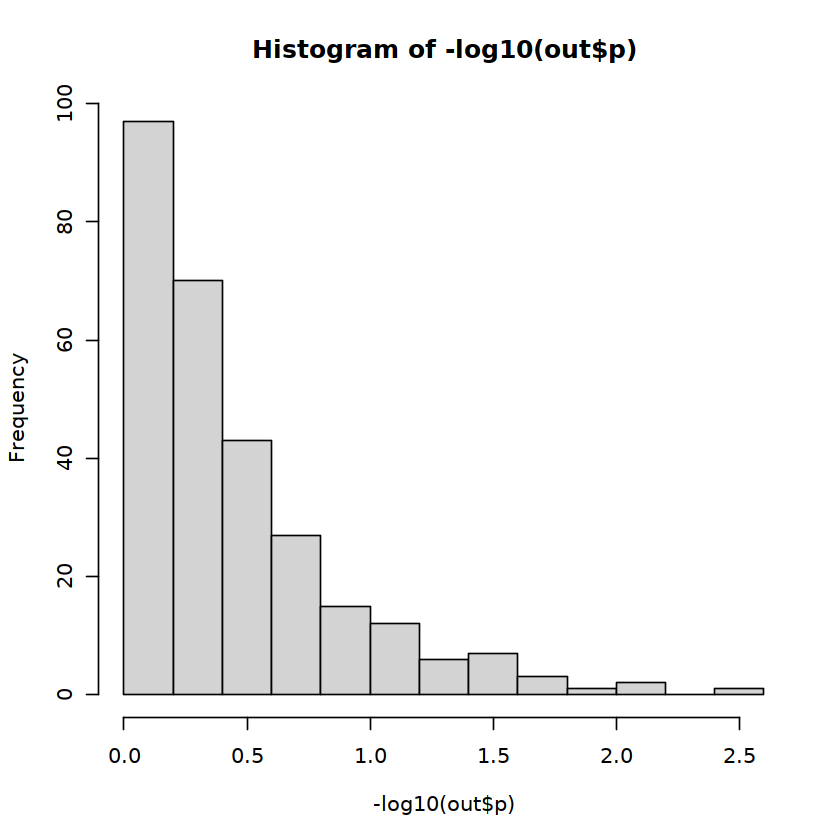

In [129]:
hist(-log10(out$p))

# 4.0 Gene knockout counts table

In [8]:
common_kos_to_exclude <- c('ENSG00000094963','ENSG00000178917','ENSG00000188163')

In [8]:
# a function to find the samples with at least one knockout in gene and fraction of total samples
get_sample_ko_table <- function(dt, categories, geneset, total_samples, knockout_annotation){

    stopifnot(!is.null(geneset))
    stopifnot(total_samples > 100)
    stopifnot(length(knockout_annotation) > 1)
    
    # get individual categories
    cat_lst <- lapply(categories, function(category){
        carry_ge_one_ko <- dt[dt$knockout == category,]
        carry_ge_one_geneset_ko <- dt[dt$knockout == category & dt$gene_id %in% geneset, ]
        n_all <- length(unique(carry_ge_one_ko$s))
        n_geneset <- length(unique(carry_ge_one_geneset_ko$s))
        res <- data.frame(
            category = category,
            n_all = n_all,
            n_pct_all = round( (n_all / total_samples) * 100, 2),
            n_geneset = n_geneset,
            n_pct_geneset = round( (n_geneset / total_samples) * 100, 2)
        ) 
        return(res)
    })

    cat_dt <- do.call(rbind, cat_lst)

    # go over combined category and get count
    carry_ge_one_ko <- dt[dt$knockout %in% knockout_annotation]
    carry_ge_one_geneset_ko <- dt[dt$knockout %in% knockout_annotation & dt$gene_id %in% geneset ]
    n_all <- length(unique(carry_ge_one_ko$s))
    n_geneset <- length(unique(carry_ge_one_geneset_ko$s))
    res <- data.frame(
            category = "Knockout",
            n_all = n_all,
            n_pct_all = round( (n_all / total_samples) * 100, 2),
            n_geneset = n_geneset,
            n_pct_geneset = round( (n_geneset / total_samples) * 100, 2)
    ) 

    final <- rbind(cat_dt, res)
    return(final)
}



In [9]:
# new nice labels and order for levels
mapping <- c(
    "Heterozygote" = "Heterozygote",
    'Homozygote' = 'Homozygote',
    "Compound heterozygote" = "Compound heterozygote",
    "Compound heterozygote (cis)" = "Two-hit (Cis)",
    "Knockout" = "Knockout"
)

In [10]:
# mapping bridge
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
hgnc_to_ensembl <- bridge$ensembl_gene_id
names(hgnc_to_ensembl) <- bridge$hgnc_symbol

# omim genes
omim <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/omim//211103_morbidmap_by_gene.txt")
omim_hgnc <- unique(omim$gene)
omim_ensgid <- unique(omim$ensgid)

In [11]:
common_kos_to_exclude <- c('ENSG00000094963','ENSG00000178917','ENSG00000188163')

In [12]:

# evaluate number of samples with at least one gene affected by a category
eval_wes_ko_geneset <- function(geneset, total_samples, exclude_ensgid = NULL){

    knockout_annotation <- c("Compound heterozygote","Homozygote")
    # read combined pLoF & damaging missense
    d <- read_ukb_wes_kos("pLoF_damaging_missense")
    if (!is.null(exclude_ensgid)) d <- d[!(d$gene_id %in% exclude_ensgid),]
    categories <- unique(d$knockout)
    d_plof_damaging_missense <- get_sample_ko_table(d, categories, geneset, total_samples, knockout_annotation)
    # read pLoF
    d <- read_ukb_wes_kos("pLoF")
    if (!is.null(exclude_ensgid)) d <- d[!(d$gene_id %in% exclude_ensgid),]
    categories <- unique(d$knockout)
    d_plof <- get_sample_ko_table(d, categories, geneset, total_samples, knockout_annotation)
    
    # read damaging missense
    d <- read_ukb_wes_kos("damaging_missense")
    if (!is.null(exclude_ensgid)) d <- d[!(d$gene_id %in% exclude_ensgid),]
    categories <- unique(d$knockout)
    d_damaging_missense <- get_sample_ko_table(d, categories, geneset, total_samples, knockout_annotation)
    
    # synonymous
    d <- read_ukb_wes_kos("synoymous")
    if (!is.null(exclude_ensgid)) d <- d[!(d$gene_id %in% exclude_ensgid),]
    categories <- unique(d$knockout)
    d_synonymous <- get_sample_ko_table(d, categories, geneset, total_samples, knockout_annotation)
    
    # other_missense
    d <- read_ukb_wes_kos("other_missense")
    if (!is.null(exclude_ensgid)) d <- d[!(d$gene_id %in% exclude_ensgid),]
    categories <- unique(d$knockout)
    d_other_missense <- get_sample_ko_table(d, categories, geneset, total_samples, knockout_annotation)
    
    # clean up names
    d_plof$category <- mapping[d_plof$category]
    d_plof_damaging_missense$category <- mapping[d_plof_damaging_missense$category]
    d_damaging_missense$category <- mapping[d_damaging_missense$category]
    d_synonymous$category <- mapping[d_synonymous$category]
    d_other_missense$category <- mapping[d_other_missense$category]
    
    # match the columns and check match
    d_plof_damaging_missense <- d_plof_damaging_missense[match(d_plof$category, d_plof_damaging_missense$category),]
    d_damaging_missense <- d_damaging_missense[match(d_plof$category, d_damaging_missense$category),]
    d_synonymous <- d_synonymous[match(d_plof$category, d_synonymous$category),]
    d_other_missense <- d_synonymous[match(d_plof$category, d_other_missense$category),]
    
    stopifnot(d_plof_damaging_missense$category == d_plof$category)
    stopifnot(d_plof_damaging_missense$category == d_damaging_missense$category)
    stopifnot(d_plof_damaging_missense$category == d_synonymous$category)
    stopifnot(d_plof_damaging_missense$category == d_other_missense$category)
    
    # collapse categories
    plof_damaging_missense <- collapse_categories(d_plof_damaging_missense, "pLoF_damaging_missense")
    damaging_missense <- plof <- collapse_categories(d_damaging_missense, "damaging_missense")
    plof <- collapse_categories(d_plof, "pLoF")
    synonymous <- collapse_categories(d_synonymous, "synonymous")
    other_missense <- collapse_categories(d_synonymous, "other_missense")
    
    # combine files
    final <- Reduce(merge, list(plof, damaging_missense, plof_damaging_missense, synonymous, other_missense))
    final <- final[match(mapping, final$category),]
    rownames(final) <- NULL
    return(final)
    
}


In [13]:
total_samples = 176587
common_kos_to_exclude <- c('ENSG00000094963','ENSG00000178917','ENSG00000188163')

In [ ]:
eval_wes_ko_geneset(omim_ensgid,  total_samples, common_kos_to_exclude)

In [289]:
transfer_plofs <- read_ukb_wes_kos_old("pLoF")
transfer_plofs <- transfer_plofs[!(transfer_plofs$gene_id %in% common_kos_to_exclude),]
transfer_genes <- transfer_plofs$gene_id[transfer_plofs$knockout == "Homozygote"]
transfer_genes <- data.table(table(transfer_genes))
colnames(transfer_genes) <- c("genes","N_transfer")

In [290]:
plofs <- read_ukb_wes_kos("pLoF")
plofs <- plofs[!(plofs$gene_id %in% common_kos_to_exclude),]

In [291]:
genes <- plofs$gene_id[plofs$knockout == "Homozygote"]
genes <- data.table(table(genes))

In [292]:
mrg <- merge(genes, transfer_genes, all = TRUE)

In [293]:
mrg[is.na(mrg)] <- 0
mrg$delta <- abs(mrg$N - mrg$N_transfer)

In [294]:
mrg <- mrg[rev(order(mrg$delta)),]
head(mrg, n = 20)

genes,N,N_transfer,delta
<chr>,<dbl>,<dbl>,<dbl>
ENSG00000198077,880,0,880
ENSG00000204880,473,0,473
ENSG00000189433,418,0,418
ENSG00000234829,312,0,312
ENSG00000164185,295,0,295
ENSG00000186364,262,0,262
ENSG00000143631,199,0,199
ENSG00000117091,198,0,198
ENSG00000128438,176,0,176


In [295]:
plofs_hom <- plofs[,c("gene_id","varid","knockout")]
plofs_hom <- plofs_hom[plofs_hom$knockout == "Homozygote",]

In [296]:
transfer_plofs_hom <- transfer_plofs[,c("gene_id","varid","knockout")]
transfer_plofs_hom <- transfer_plofs_hom[transfer_plofs_hom$knockout == "Homozygote",]

In [297]:
table(plofs_hom[plofs_hom$gene_id %in% mrg$genes[1],]$varid)
table(transfer_plofs_hom[transfer_plofs_hom$gene_id %in% mrg$genes[1],]$varid)
any(transfer_plofs_hom$gene_id %in% mrg$genes[1])


chr19:40875778:G:T chr19:40877995:T:G 
               879                  1 

< table of extent 0 >

[1] FALSE

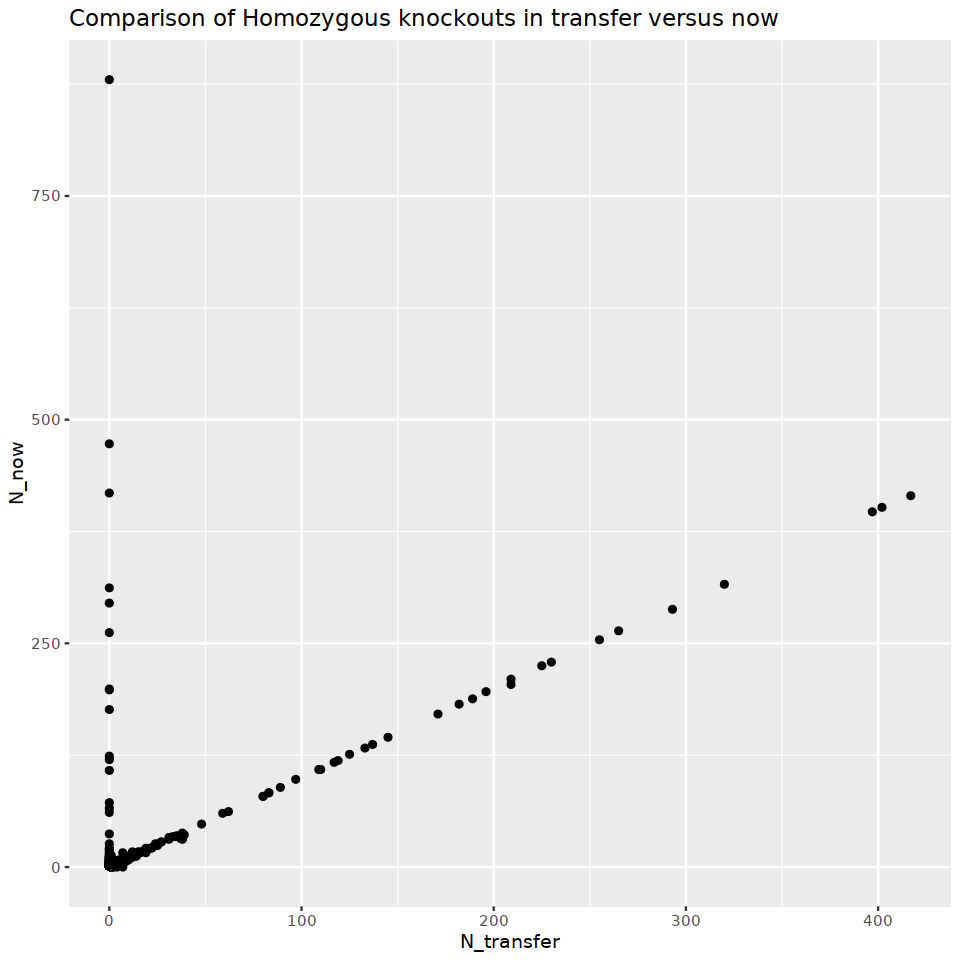

In [298]:
ggplot(mrg, aes(x=N_transfer, N)) +
    geom_point() + 
    ylab("N_now") +
    ggtitle("Comparison of Homozygous knockouts in transfer versus now")

# Model by geneset

# Unique genes affected

ERROR: Error in library(pscl): there is no package called 'pscl'


In [167]:
check_geneset <- function(dt, geneset, to_real_table = TRUE){
    
    df <- dt
    df$geneset <- df$gene_id %in% geneset
    gene_df <- aggregate(gene_id ~ geneset + knockout, data = df, FUN = length)
    gene_df <- gene_df[gene_df$geneset == TRUE,]
    colnames(gene_df)[3] <- "n"
    gene_df$geneset_size <- length(unique(geneset))
    gene_df$pct_of_geneset <- round((gene_df$n / gene_df$geneset_size) * 100,1)
    gene_df$geneset <- NULL
    rownames(gene_df) <- NULL
    
    if (to_real_table){
        gene_df$geneset_size <- NULL
        gene_df$n <- paste0(gene_df$n, ' (', gene_df$pct_of_geneset, '%)')
        gene_df$pct_of_geneset <- NULL
    }
    
    return(gene_df)
}



In [176]:
dt <- dt_plof_missense
head(dt)

gene_id,s,gts,varid,hom_alt_n,phased.a1,phased.a2,unphased.n,pKO,knockout
<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<chr>
ENSG00000000457,1008716,"[""0|1""]","[""chr1:169876054:A:G""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1016311,"[""0|1""]","[""chr1:169868968:G:A""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1017844,"[""0|1""]","[""chr1:169876054:A:G""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1018695,"[""0|1""]","[""chr1:169876054:A:G""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1020249,"[""0|1""]","[""chr1:169876054:A:G""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1025619,"[""1|0""]","[""chr1:169876054:A:G""]",0,1,0,0,0,Heterozygote


In [178]:
length(unique(dt[dt$pKO == 1]$gene_id))

[1] 2904

In [197]:
dt <- dt_plof #dt_plof_missense
dt <- dt[,c("gene_id", "knockout",'pKO')]
dt <- dt[!duplicated(dt),]
ndt <- dt[(dt$pKO == 1)]
ndt$knockout <- "Knockout"
ndt <- ndt[!duplicated(ndt$gene_id),]
dt <- rbind(dt, ndt)

# protein coding
coding <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart//protein_coding_genes.tsv") 

# omim genes
omim <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/omim//211103_morbidmap_by_gene.txt")
omim_hgnc <- unique(omim$gene)
omim_ensgid <- unique(omim$ensgid)

# gtex brain
gtex <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gtex/GTEx.tstat.tsv")
gtex_brain <- gtex$ENSGID[gtex$Brain_Cortex >= quantile(gtex$Brain_Cortex, probs = 0.9)]

# gnomad
gnomad_genes <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_13_gene_lists.tsv")
gnomad_genes$gene_id <- hgnc_to_ensembl[gnomad_genes$gene]
genes_auto_dom <- gnomad_genes$gene_id[gnomad_genes$gene_list %in% "Autosomal Dominant"]
genes_auto_rec <- gnomad_genes$gene_id[gnomad_genes$gene_list %in% "Autosomal Recessive"]
genes_olf <- gnomad_genes$gene_id[gnomad_genes$gene_list %in% "Olfactory Genes"]
genes_hap <- gnomad_genes$gene_id[gnomad_genes$gene_list %in% "Haploinsufficient"]

 
genes <- check_geneset(dt, unique(dt$gene_id))
colnames(genes)[2] <- "Genes n (% of geneset)"
protein_coding <- check_geneset(dt, unique(coding$ensembl_gene_id))
colnames(protein_coding)[2] <- "Protein Coding n (% of geneset)"
omim <- check_geneset(dt, omim_ensgid)
colnames(omim)[2] <- "OMIM n (% of geneset)"
dom <- check_geneset(dt, genes_auto_dom)
colnames(dom)[2] <- "Autosomal Dominant n (% of geneset)"
rec <- check_geneset(dt, genes_auto_rec)
colnames(rec)[2] <- "Autosomal Recessive n (% of geneset)"
olf <- check_geneset(dt, genes_olf)
colnames(olf)[2] <- "Olfactory Genes n (% of geneset)"
hap <- check_geneset(dt, genes_hap)
colnames(hap)[2] <- "Haploinsufficient n (% of geneset)"

final <- Reduce(merge, list(genes, protein_coding, omim, dom, rec, olf))
final$knockout <- mapping[final$knockout]
final <- final[c(3,2,1,6,4,5),]
rownames(final) <- NULL
final

knockout,Genes n (% of geneset),Protein Coding n (% of geneset),OMIM n (% of geneset),Autosomal Dominant n (% of geneset),Autosomal Recessive n (% of geneset),Olfactory Genes n (% of geneset)
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Heterozygote,15883 (99.6%),15605 (71.2%),3617 (83.6%),572 (81.7%),1099 (95.3%),162 (45.8%)
Compound heterozygote (Cis),1346 (8.4%),1329 (6.1%),361 (8.3%),49 (7%),125 (10.8%),9 (2.5%)
Compound heterozygote (Trans),542 (3.4%),533 (2.4%),102 (2.4%),17 (2.4%),33 (2.9%),6 (1.7%)
Compound heterozygote (Unknown),1265 (7.9%),1253 (5.7%),342 (7.9%),43 (6.1%),120 (10.4%),6 (1.7%)
Homozygote,759 (4.8%),744 (3.4%),113 (2.6%),15 (2.1%),43 (3.7%),9 (2.5%)
Knockout,1014 (6.4%),996 (4.5%),172 (4%),24 (3.4%),64 (5.6%),13 (3.7%)


In [140]:
0.0000000000150776

[1] 1.50776e-11

# Genes affected by knockout count

In [141]:
#autosomes = 1:22
#lst <- lapply(autosomes, function(chr){
#    path <- paste0("data/knockouts/alt//ukb_eur_wes_200k_chrCHR_maf0to5e-2_pLoF_damaging_missense_all.tsv.gz")
#    path <- gsub("CHR",chr, path)
#    d <- fread(path)
#    return(d)
#})
#
#dt <- setDT(do.call(rbind, lst))
## total samples in data
#total_samples = 176915
## categories to be assessed
#categories <- unique(dt$knockout)
## what constitutes a full knockout?
#knockout_annotation <- c("Compound heterozygote","Homozygote")

In [142]:
#dt_gene <- dt[dt$knockout %in% knockout_annotation & dt$pKO == 1,]
#dt_gene <- as.data.table(table(dt_gene$gene_id, dt_gene$knockout))
#colnames(dt_gene) <- c("gene","knockout","count")
#dt_gene <- dcast(gene~knockout, value.var = "count", data = dt_gene)
#dt_gene$knockout <- dt_gene$`Compound heterozygote` + dt_gene$Homozygote
#dt_gene$hgnc_symbol <- ensembl_to_hgnc[dt_gene$gene]
#dt_gene <- dt_gene[,c(1,5,2,3,4)]
#dt_gene <- dt_gene[rev(order(dt_gene$knockout)),]

In [143]:
#sum(dt_gene$knockout > 1); nrow(dt_gene)

In [148]:
d <- fread("data/post_hoc/results/pLoF_damaging_missense_maf0to5e-2_knockouts_by_genes.txt.gz")

In [149]:
d$knockouts <- d$`CHET-TRANS` + d$HOM
d <- d[d$knockouts > 0,]
d$hgnc_symbol <- ensembl_to_hgnc[d$ensembl_gene_id]
d <- d[rev(order(d$knockout)),]

In [151]:
options(repr.matrix.max.rows=100, repr.matrix.max.cols=50)
nrow(d)
d

[1] 2904

hgnc_symbol,ensembl_gene_id,CHET-CIS,CHET-TRANS,CHET-UNKNOWN,HET,HOM,knockouts
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
PKHD1L1,ENSG00000205038,98,322,17,21023,398,720
FMO2,ENSG00000094963,1,168,2,18265,353,521
GMPR2,ENSG00000100938,3,17,6,16587,424,441
UBE2W,ENSG00000104343,0,1,2,15740,417,418
ANKLE1,ENSG00000160117,15,15,0,16384,402,417
ATP6V0A4,ENSG00000105929,22,25,7,16425,356,381
AMPD1,ENSG00000116748,16,115,10,14288,210,325
ETFB,ENSG00000105379,29,4,2,14371,320,324
MICA,ENSG00000204520,9,29,0,14628,293,322


In [ ]:
d <- fread("data/post_hoc/results/")

In [125]:
d <- fread("data/post_hoc/results/pLoF_damaging_missense_maf0to5e-2_knockouts_by_phenotypes.txt.gz")
d <- d[!grepl("primary_care",d$phenotype),]
d$knockout <- d$`CHET-TRANS` + d$HOM
d <- d[rev(order(d$knockout)),]
d

phenotype,CHET-CIS,CHET-TRANS,CHET-UNKNOWN,HET,HOM,phenos_na,cases_all,controls_all,cases_nfe,controls_nfe,knockout
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
genetic.eur.no.fin.oct2021,61489,11946,3831,6553880,14977,0,176594,0,176594,0,26923
genetic.eur.oct2021,61489,11946,3831,6553880,14977,0,176594,0,176594,0,26923
CAD_combined,6980,1350,407,734727,1630,30,19778,156786,19778,156786,2980
RF_combined,3991,838,268,421223,962,0,11331,165263,11331,165263,1800
DEP_combined,3529,709,229,381260,873,0,10252,166342,10252,166342,1582
COPD_combined,3051,637,165,334566,730,0,8993,167601,8993,167601,1367
HEM_combined,2935,598,166,318621,751,0,8580,168014,8580,168014,1349
BC_combined,2848,566,175,298954,701,0,8035,168559,8035,168559,1267
RF_acute_combined,2319,508,156,244664,577,4753,6578,165263,6578,165263,1085


# Fraction of variant consequence by Compound Het

In [416]:
d <- fread( paste0("data/knockouts/tables/pLoF_damaging_missense_full_chr21.txt.gz"))
d <- d[d$pKO > 0.5]
d$knockout <- mapping[d$knockout]

In [417]:
head(d)

gene_id,s,gts,varid,hom_alt_n,phased.a1,phased.a2,unphased.n,pKO,knockout,⋯,cadd_phred,most_severe_csqs,AF,AC,AN,gene_symbol,exon,codon,amino_acids,chr
<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
ENSG00000141956,2693945,"0|1, 1|0","chr21:41861739:TG:T, chr21:41878845:C:CA",0,1,1,0,1,Compound heterozygote (Trans),⋯,"NA, NA, NA, NA","frameshift_variant, frameshift_variant, upstream_gene_variant, upstream_gene_variant","2.5436e-05, 3.6741e-05, 3.6741e-05, 3.6741e-05","2.5436e-05, 3.6741e-05, 3.6741e-05, 3.6741e-05","353830, 353830, 353830, 353830","PRDM15, PRDM15, AP001619.1, RF00334","7/31, 3/31, NA, NA","ttC/tt, cgg/cTgg, NA, NA","F/X, R/LX, NA, NA",21
ENSG00000141959,1609598,"1|0, 0|1","chr21:44316307:G:A, chr21:44316316:A:C",0,1,1,0,1,Compound heterozygote (Trans),⋯,"24.9, 25.1","missense_variant, missense_variant","0.00011022, 9.0439e-05","0.00011022, 9.0439e-05","353830, 353830","PFKL, PFKL","8/22, 8/22","Ggg/Agg, Atc/Ctc","G/R, I/L",21
ENSG00000141959,1799167,1|1,chr21:44325182:C:A,1,0,0,0,1,Homozygote,⋯,"25.9, NA, NA","missense_variant, downstream_gene_variant, downstream_gene_variant","0.0018512, 0.0018512, 0.0018512","0.0018512, 0.0018512, 0.0018512","353830, 353830, 353830","PFKL, AP001062.3, CFAP410","19/22, NA, NA","aCg/aAg, NA, NA","T/K, NA, NA",21
ENSG00000141959,2657302,"1|0, 0|1","chr21:44313116:T:C, chr21:44316307:G:A",0,1,1,0,1,Compound heterozygote (Trans),⋯,"27.3, 24.9","missense_variant, missense_variant","0.00029393, 0.00011022","0.00029393, 0.00011022","353830, 353830","PFKL, PFKL","5/22, 8/22","aTc/aCc, Ggg/Agg","I/T, G/R",21
ENSG00000141959,4327625,"0|1, 1|0","chr21:44316290:G:T, chr21:44316307:G:A",0,1,1,0,1,Compound heterozygote (Trans),⋯,"25, 24.9","missense_variant, missense_variant","5.6524e-06, 0.00011022","5.6524e-06, 0.00011022","353830, 353830","PFKL, PFKL","8/22, 8/22","gGt/gTt, Ggg/Agg","G/V, G/R",21
ENSG00000142156,1516508,"0|1, 1|0","chr21:45984391:T:C, chr21:45999190:A:C",0,1,1,0,1,Compound heterozygote (Trans),⋯,"25.3, 27","missense_variant, missense_variant","0.0016816, 0.00040415","0.0016816, 0.00040415","353830, 353830","COL6A1, COL6A1","3/35, 26/35","gTg/gCg, aAg/aCg","V/A, K/T",21


In [419]:
colnames(d)

[1] "gene_id"          "s"                "gts"              "varid"           
 [5] "hom_alt_n"        "phased.a1"        "phased.a2"        "unphased.n"      
 [9] "pKO"              "knockout"         "revel_score"      "cadd_phred"      
[13] "most_severe_csqs" "AF"               "AC"               "AN"              
[17] "gene_symbol"      "exon"             "codon"            "amino_acids"     
[21] "chr"

In [420]:
print(d[1,])

           gene_id       s      gts                                    varid
1: ENSG00000141956 2693945 0|1, 1|0 chr21:41861739:TG:T, chr21:41878845:C:CA
   hom_alt_n phased.a1 phased.a2 unphased.n pKO                      knockout
1:         0         1         1          0   1 Compound heterozygote (Trans)
      revel_score     cadd_phred
1: NA, NA, NA, NA NA, NA, NA, NA
                                                                       most_severe_csqs
1: frameshift_variant, frameshift_variant, upstream_gene_variant, upstream_gene_variant
                                               AF
1: 2.5436e-05, 3.6741e-05, 3.6741e-05, 3.6741e-05
                                               AC
1: 2.5436e-05, 3.6741e-05, 3.6741e-05, 3.6741e-05
                               AN                         gene_symbol
1: 353830, 353830, 353830, 353830 PRDM15, PRDM15, AP001619.1, RF00334
                 exon                    codon       amino_acids chr
1: 7/31, 3/31, NA, NA ttC/tt, cgg/cTgg,

In [421]:
vep <- fread(paste0('data/mt/vep/worst_csq_by_gene_canonical/ukb_eur_wes_union_calls_200k_chr',chr,'.tsv.gz'))

In [422]:
colnames(vep)

[1] "locus"                        "alleles"                     
 [3] "rsid"                         "info.AC"                     
 [5] "info.AF"                      "info.AN"                     
 [7] "MAF"                          "MAC"                         
 [9] "varid"                        "csqs.allele_num"             
[11] "csqs.amino_acids"             "csqs.biotype"                
[13] "csqs.canonical"               "csqs.ccds"                   
[15] "csqs.cdna_start"              "csqs.cdna_end"               
[17] "csqs.cds_end"                 "csqs.cds_start"              
[19] "csqs.codons"                  "csqs.consequence_terms"      
[21] "csqs.distance"                "csqs.domains"                
[23] "csqs.exon"                    "csqs.gene_id"                
[25] "csqs.gene_pheno"              "csqs.gene_symbol"            
[27] "csqs.gene_symbol_source"      "csqs.hgnc_id"                
[29] "csqs.hgvsc"                   "csqs.hgvsp"                  
[31] "csqs.hgvs_offset"             "csqs.impact"                 
[33] "csqs.intron"                  "csqs.lof"                    
[35] "csqs.lof_flags"               "csqs.lof_filter"             
[37] "csqs.lof_info"                "csqs.minimised"              
[39] "csqs.polyphen_prediction"     "csqs.polyphen_score"         
[41] "csqs.protein_end"             "csqs.protein_start"          
[43] "csqs.protein_id"              "csqs.sift_prediction"        
[45] "csqs.strand"                  "csqs.swissprot"              
[47] "csqs.transcript_id"           "csqs.trembl"                 
[49] "csqs.uniparc"                 "csqs.variant_allele"         
[51] "csqs.revel_score"             "csqs.cadd_phred"             
[53] "csqs.most_severe_consequence" "csqs.csq_score"              
[55] "consequence_category"

In [424]:
print(head(vep$consequence_category))

[1] "non_coding" "non_coding" "non_coding" "non_coding" "non_coding"
[6] "non_coding"
